# Sign Language Gesture Recognition using CNN
**Module:** 6CS012 – Artificial Intelligence and Machine Learning  
**Assessment:** Final Portfolio – Part II: Vision Tasks  
**Dataset:** Sign Language Detection (38 classes, ~10 800 training images)  

### Notebook Contents
1. Libraries & seeds  
2. Mount Drive, copy ZIP, extract dataset  
3. Auto-detect Train / Test directories  
4. Image cleaning  
5. Dataset statistics & class distribution  
6. Sample visualisation & data augmentation  
7. Data generators  
8. Helper functions (training curves, evaluation, confusion matrix)  
9. **Part A – CNN from Scratch**  
   - 9a. Baseline CNN (3 conv + pooling + 3 FCN)  
   - 9b. Deeper CNN with BatchNorm + Dropout  
   - 9c. Optimizer comparison: Adam vs SGD  
   - 9d. Ablation study (remove Dropout)  
10. **Part B – Transfer Learning with EfficientNetB0**  
11. Final comparison table  



## 1. Import Libraries & Set Random Seeds

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
import os
from PIL import Image
import random
import time

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD
SEED = 21

from sklearn.metrics import classification_report, confusion_matrix

In [9]:
train_path = '/content/drive/MyDrive/AI_Final_Assesment/Train'
test_path = '/content/drive/MyDrive/AI_Final_Assesment/Test'

In [10]:
TRAIN_DIR = train_path
TEST_DIR  = test_path

## 3. Sanity Check – Count Images

In [11]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(folder):
    if not folder or not os.path.isdir(folder):
        return 0
    return sum(
        1 for _, _, files in os.walk(folder)
        for f in files if f.lower().endswith(tuple(IMG_EXTS))
    )

print(f"Training images : {count_images(train_path)}")
print(f"Test images     : {count_images(test_path)}")

Training images : 4979
Test images     : 3


## 4. Remove Corrupted / Non-Image Files

In [12]:
from pathlib import Path

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images(folder):
    if not folder or not os.path.isdir(folder):
        return 0
    return sum(
        1 for _, _, files in os.walk(folder)
        for f in files if Path(f).suffix.lower() in IMG_EXTS
    )

print(f"Training images : {count_images(TRAIN_DIR)}")
print(f"Test images     : {count_images(TEST_DIR)}")

USE_VAL_SPLIT = (count_images(TEST_DIR) < 50)
if USE_VAL_SPLIT:
    print("\nTest set is very small -> using 20% validation split from training data for evaluation.")

Training images : 4979
Test images     : 3

Test set is very small -> using 20% validation split from training data for evaluation.


## 5. Dataset Statistics & Class Distribution

Number of classes : 18
Total train images: 4979
Min images/class  : 134
Max images/class  : 293
Mean images/class : 276.6

Class  Count
    0    286
   10    291
   11    284
   13    279
   14    270
   15    287
   16    291
   17    286
   20    286
   22    293
   27    286
   28    284
    3    134
   32    281
   34    283
   36    282
   37    289
    5    287


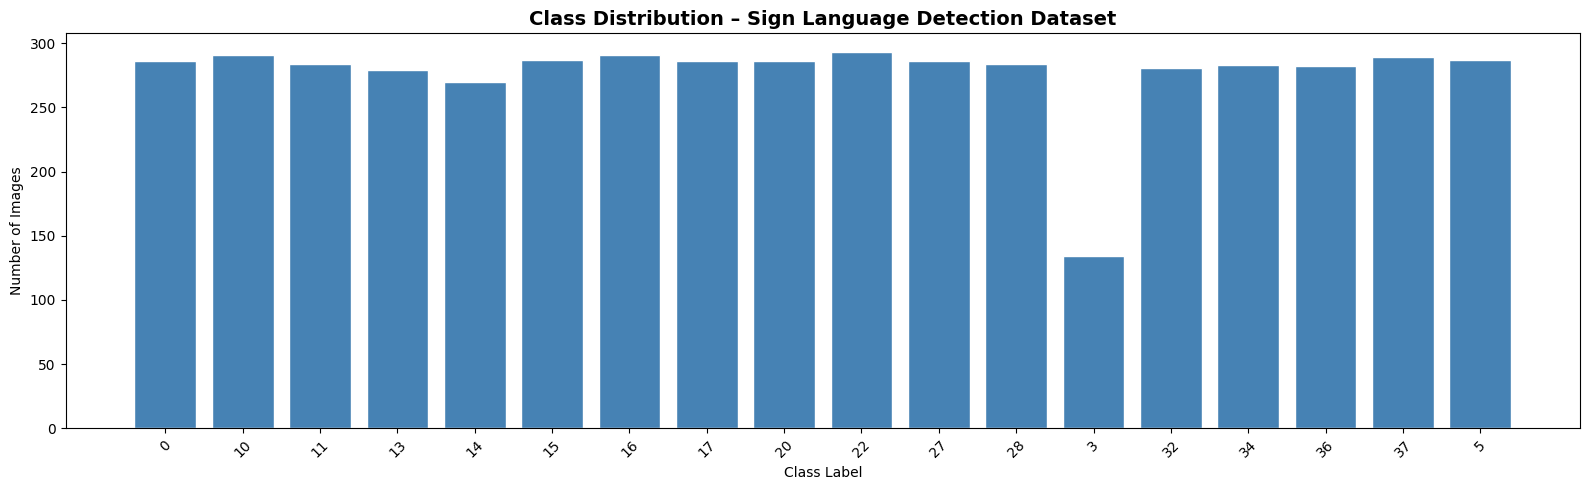

In [13]:
# Count images per class
class_counts = {}
for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = count_images(cls_path)

df_counts = pd.DataFrame(list(class_counts.items()), columns=["Class", "Count"])
df_counts = df_counts.sort_values("Class").reset_index(drop=True)

NUM_CLASSES   = len(df_counts)
TOTAL_IMAGES  = df_counts["Count"].sum()

print(f"Number of classes : {NUM_CLASSES}")
print(f"Total train images: {TOTAL_IMAGES}")
print(f"Min images/class  : {df_counts['Count'].min()}")
print(f"Max images/class  : {df_counts['Count'].max()}")
print(f"Mean images/class : {df_counts['Count'].mean():.1f}")
print()
print(df_counts.to_string(index=False))

# Bar chart
plt.figure(figsize=(16, 5))
plt.bar(df_counts["Class"].astype(str), df_counts["Count"], color="steelblue", edgecolor="white")
plt.title("Class Distribution – Sign Language Detection Dataset", fontsize=14, fontweight="bold")
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Sample Images & Data Augmentation Visualisation

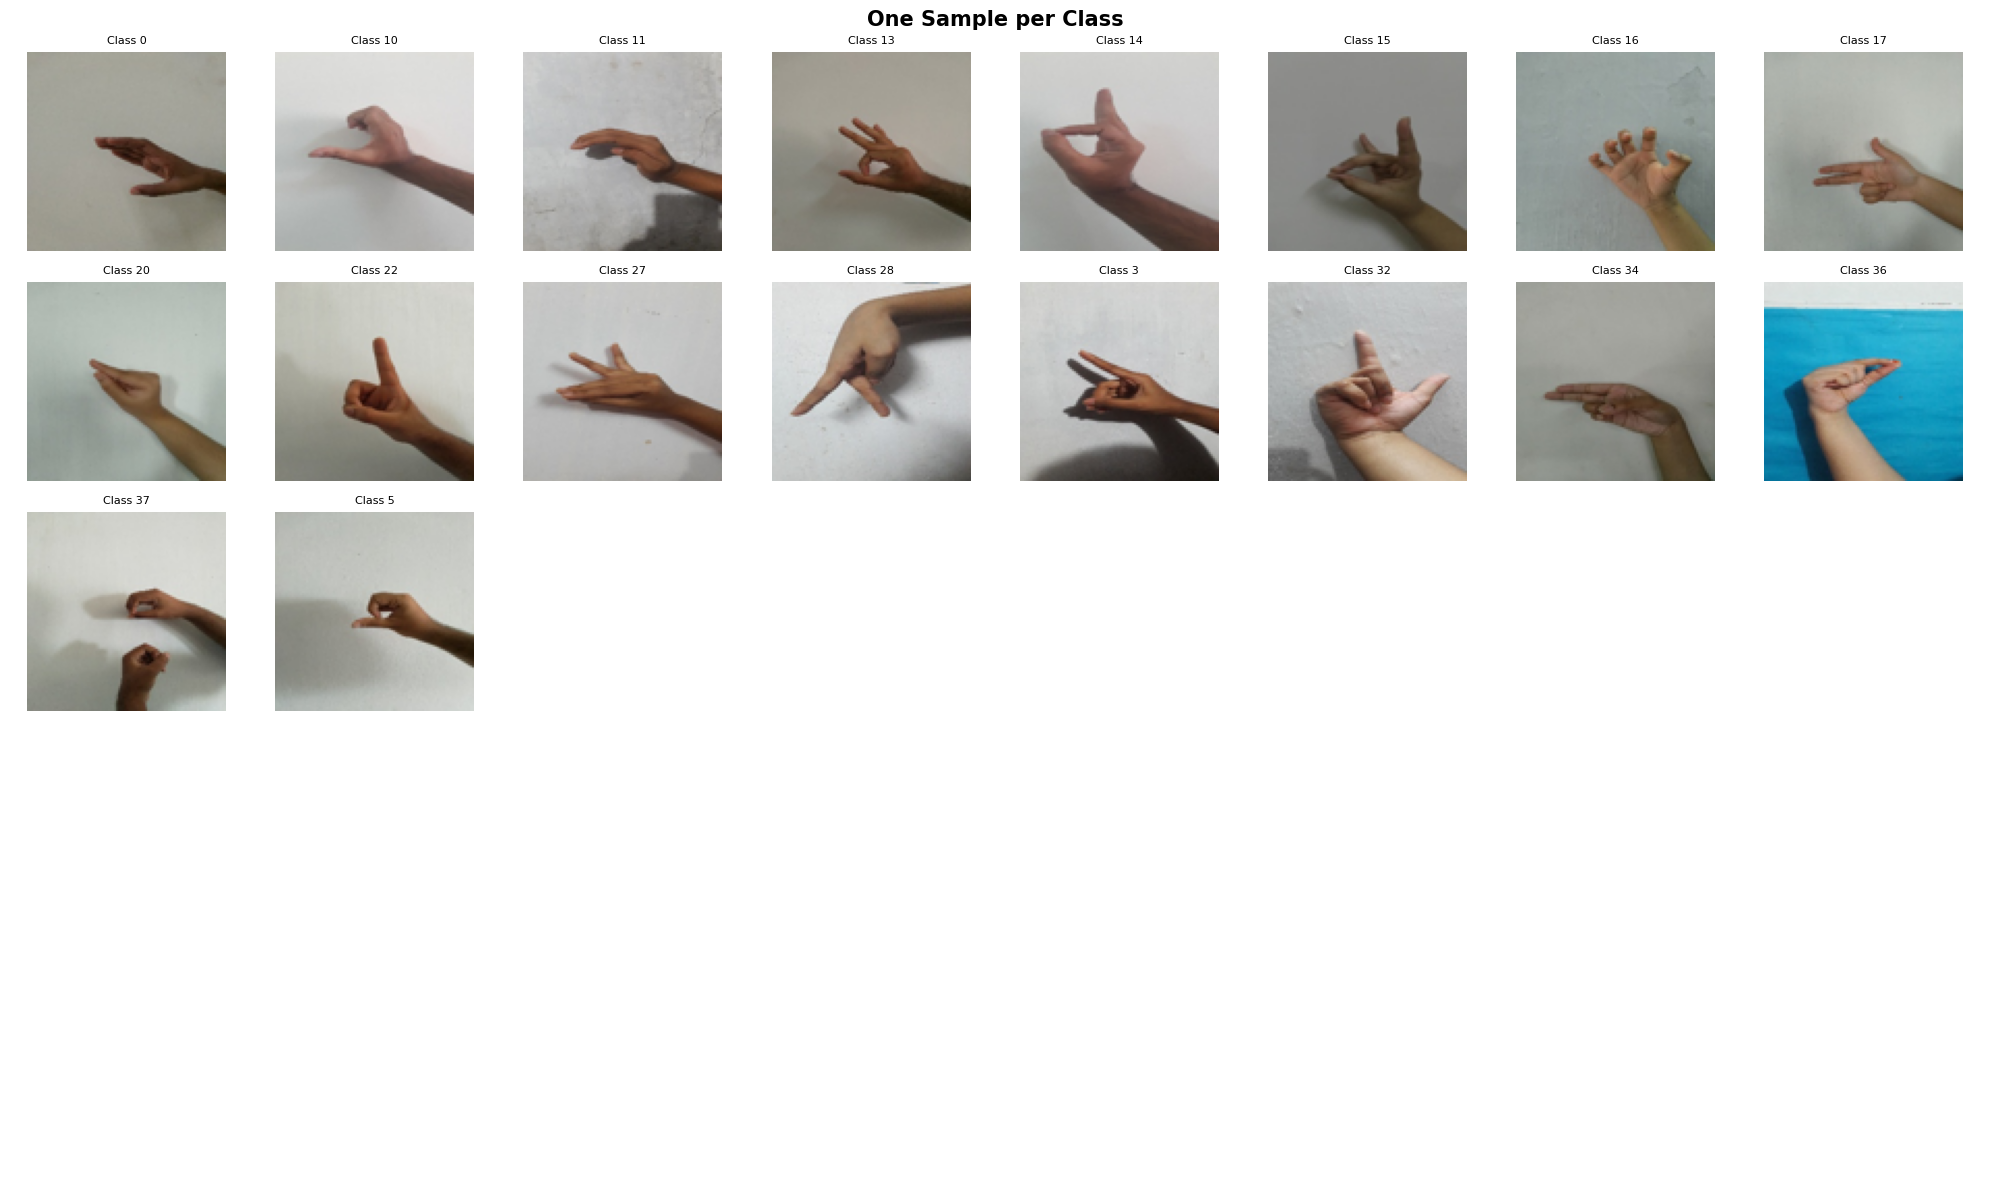

In [14]:
# Sample one image per class
fig, axes = plt.subplots(5, 8, figsize=(20, 12))
axes = axes.flatten()
for idx, cls in enumerate(sorted(class_counts.keys())):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_path) if Path(f).suffix.lower() in IMG_EXTS]
    if not imgs:
        continue
    img = Image.open(os.path.join(cls_path, random.choice(imgs))).convert("RGB").resize((96, 96))
    axes[idx].imshow(img)
    axes[idx].set_title(f"Class {cls}", fontsize=8)
    axes[idx].axis("off")
for ax in axes[NUM_CLASSES:]:
    ax.axis("off")
plt.suptitle("One Sample per Class", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


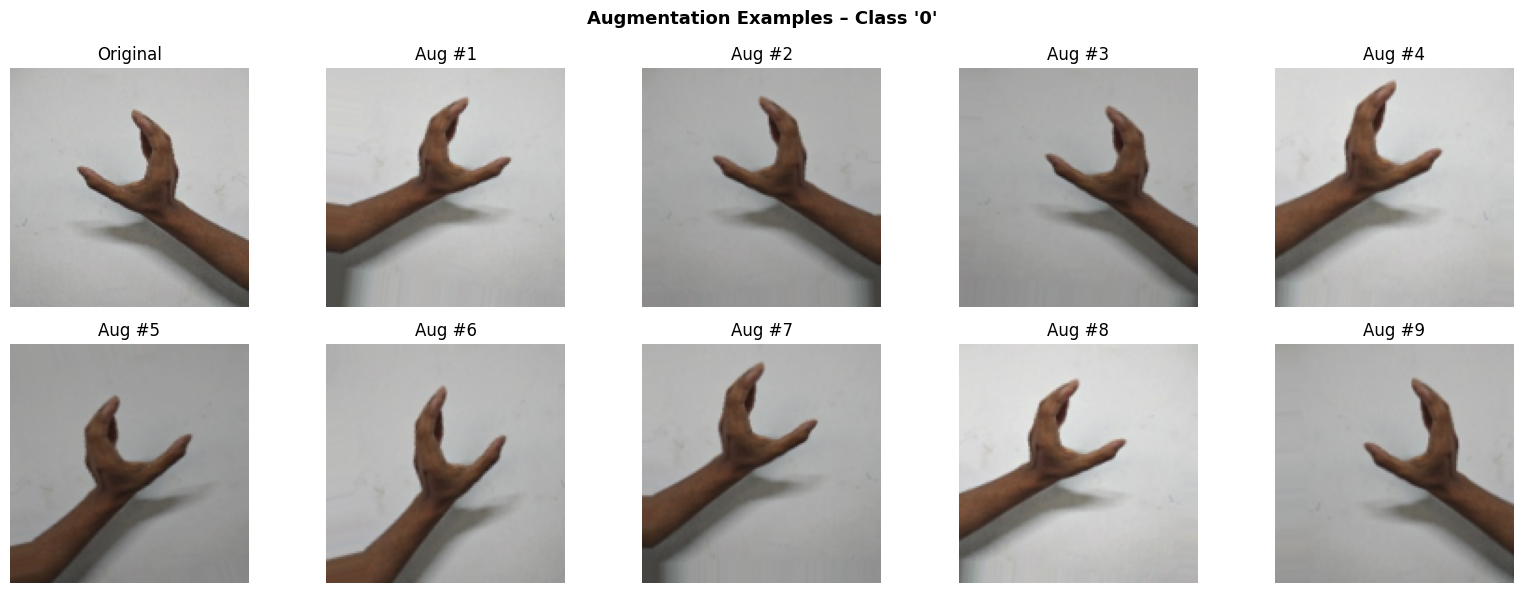

In [15]:
# Show augmented samples for one class
aug_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    zoom_range=0.1,
    fill_mode="nearest",
    rescale=1.0/255
)

sample_cls  = sorted(class_counts.keys())[0]
sample_dir  = os.path.join(TRAIN_DIR, sample_cls)
sample_file = next(
    f for f in os.listdir(sample_dir)
    if Path(f).suffix.lower() in IMG_EXTS
)
sample_path = os.path.join(sample_dir, sample_file)
sample_arr  = np.array(Image.open(sample_path).convert("RGB").resize((128, 128)))
sample_arr  = sample_arr.reshape((1,) + sample_arr.shape)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
axes[0].imshow(sample_arr[0])
axes[0].set_title("Original")
axes[0].axis("off")

aug_iter = aug_gen.flow(sample_arr, batch_size=1)
for i in range(1, 10):
    batch = next(aug_iter)
    axes[i].imshow(batch[0])
    axes[i].set_title(f"Aug #{i}")
    axes[i].axis("off")
plt.suptitle(f"Augmentation Examples – Class '{sample_cls}'", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Data Generators

In [16]:
IMG_SIZE  = (128, 128)
BATCH     = 32
VAL_SPLIT = 0.20

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    zoom_range=0.10,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
    validation_split=VAL_SPLIT
)

# Validation / test generator – only rescaling, no augmentation
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VAL_SPLIT
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

NUM_CLASSES = train_gen.num_classes
print(f"Training samples  : {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Number of classes : {NUM_CLASSES}")
print(f"Class indices (first 5): {dict(list(train_gen.class_indices.items())[:5])}")


Found 3991 images belonging to 18 classes.
Found 988 images belonging to 18 classes.
Training samples  : 3991
Validation samples: 988
Number of classes : 18
Class indices (first 5): {'0': 0, '10': 1, '11': 2, '13': 3, '14': 4}


## 8. Shared Helper Functions

In [17]:
# ── Training-curve plotter ──────────────────────────────────────────
def plot_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history["accuracy"],     label="Train Acc")
    axes[0].plot(history.history["val_accuracy"], label="Val Acc")
    axes[0].set_title(f"{model_name} – Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(history.history["loss"],     label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Val Loss")
    axes[1].set_title(f"{model_name} – Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True)

    plt.suptitle(model_name, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ── Confusion-matrix plotter ────────────────────────────────────────
def plot_cm(cm, class_labels, model_name):
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f"{model_name} – Confusion Matrix", fontsize=14, fontweight="bold")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0,  fontsize=7)
    plt.tight_layout()
    plt.show()


# ── Full evaluation ──────────────────────────────────────────────────
def evaluate_model(model, gen, model_name):
    gen.reset()
    y_prob = model.predict(gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = gen.classes

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred,    average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred,        average="weighted", zero_division=0)

    print("=" * 55)
    print(f"  {model_name}")
    print("=" * 55)
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print("=" * 55)

    labels = list(gen.class_indices.keys())
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plot_cm(cm, labels, model_name)

    return {"model": model_name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


# Shared EarlyStopping + ReduceLR callbacks
def get_callbacks(monitor="val_loss"):
    return [
        EarlyStopping(monitor=monitor, patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor=monitor, factor=0.3, patience=3, min_lr=1e-7, verbose=1)
    ]


# Store all results for final comparison table
all_results = []


## 9a. Baseline CNN – 3 Conv Blocks + 3 Fully-Connected Layers

**Architecture rationale:**  
- 3 Conv layers (32 → 64 → 128 filters, 3×3 kernels, ReLU) each followed by 2×2 MaxPooling  
- Flatten → Dense(256) → Dense(128) → Dense(64) → output softmax  
- Adam optimiser, categorical cross-entropy loss  


In [18]:
def build_baseline_cnn(num_classes, img_size=(128, 128, 3)):
    model = Sequential([
        Input(shape=img_size),

        # Block 1
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Block 2
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        # Block 3
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),

        Flatten(),

        # FCN 1
        Dense(256, activation="relu"),
        # FCN 2
        Dense(128, activation="relu"),
        # FCN 3
        Dense(64, activation="relu"),

        # Output
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_cnn(NUM_CLASSES)
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,524,434 (32.52 MB)

 Trainable params: 8,524,434 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

### Train Baseline CNN

In [24]:
t0 = time.time()

history_baseline = baseline_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=get_callbacks(),
    verbose=1
)

baseline_time = time.time() - t0
print(f"\nBaseline CNN training time: {baseline_time:.1f}s ({baseline_time/60:.1f} min)")


Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 313ms/step - accuracy: 0.1917 - loss: 2.5778 - val_accuracy: 0.2490 - val_loss: 2.4133 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 300ms/step - accuracy: 0.2526 - loss: 2.3089 - val_accuracy: 0.2834 - val_loss: 2.2044 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 304ms/step - accuracy: 0.3327 - loss: 2.0870 - val_accuracy: 0.3704 - val_loss: 1.9188 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 305ms/step - accuracy: 0.3931 - loss: 1.8351 - val_accuracy: 0.3988 - val_loss: 1.8655 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 301ms/step - accuracy: 0.4600 - loss: 1.6438 - val_accuracy: 0.4494 - val_loss: 1.7657 - learning_rate: 0.0010
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 299ms/step - accuracy: 0.5269 - loss: 1.4290 - val_accuracy: 0.4737 - val_loss: 1.5968 - learning_rate: 0.0010
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 309ms/step - accuracy: 0.5

### Evaluate Baseline CNN

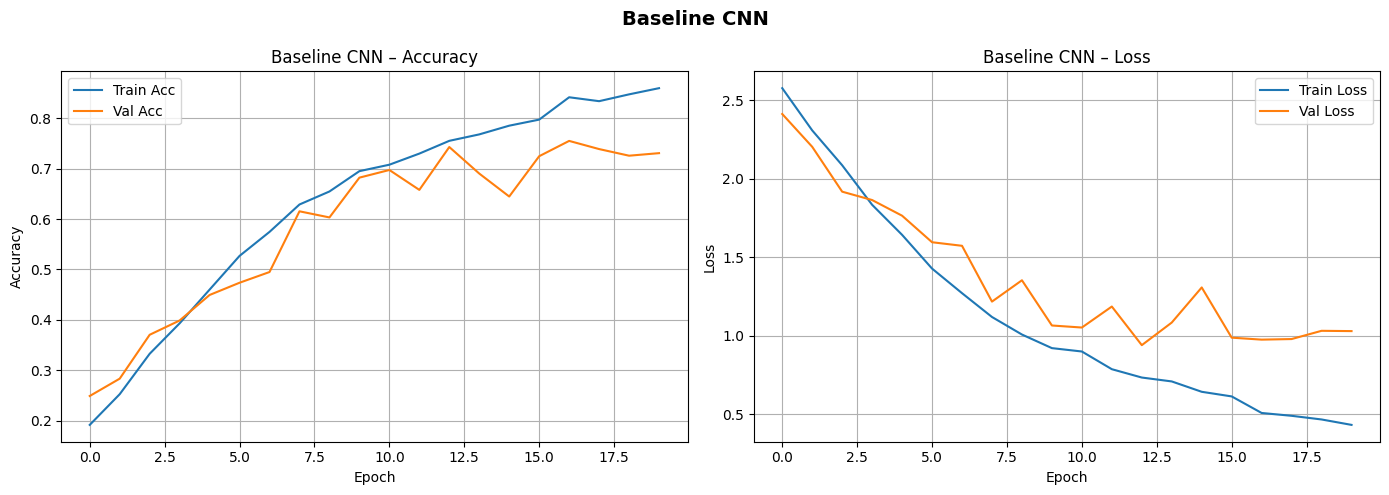

31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 122ms/step
  Baseline CNN
  Accuracy : 0.7429
  Precision: 0.7588
  Recall   : 0.7429
  F1-Score : 0.7430

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82        57
          10       0.86      0.83      0.84        58
          11       0.75      0.71      0.73        56
          13       0.53      0.75      0.62        55
          14       0.78      0.59      0.67        54
          15       0.78      0.61      0.69        57
          16       0.78      0.88      0.83        58
          17       0.81      0.75      0.78        57
          20       0.80      0.70      0.75        57
          22       0.71      0.79      0.75        58
          27       0.73      0.67      0.70        57
          28       0.82      0.82      0.82        56
           3       0.85      0.42      0.56        26
          32       0.76      0.75      0.76        56
          34       0.78      

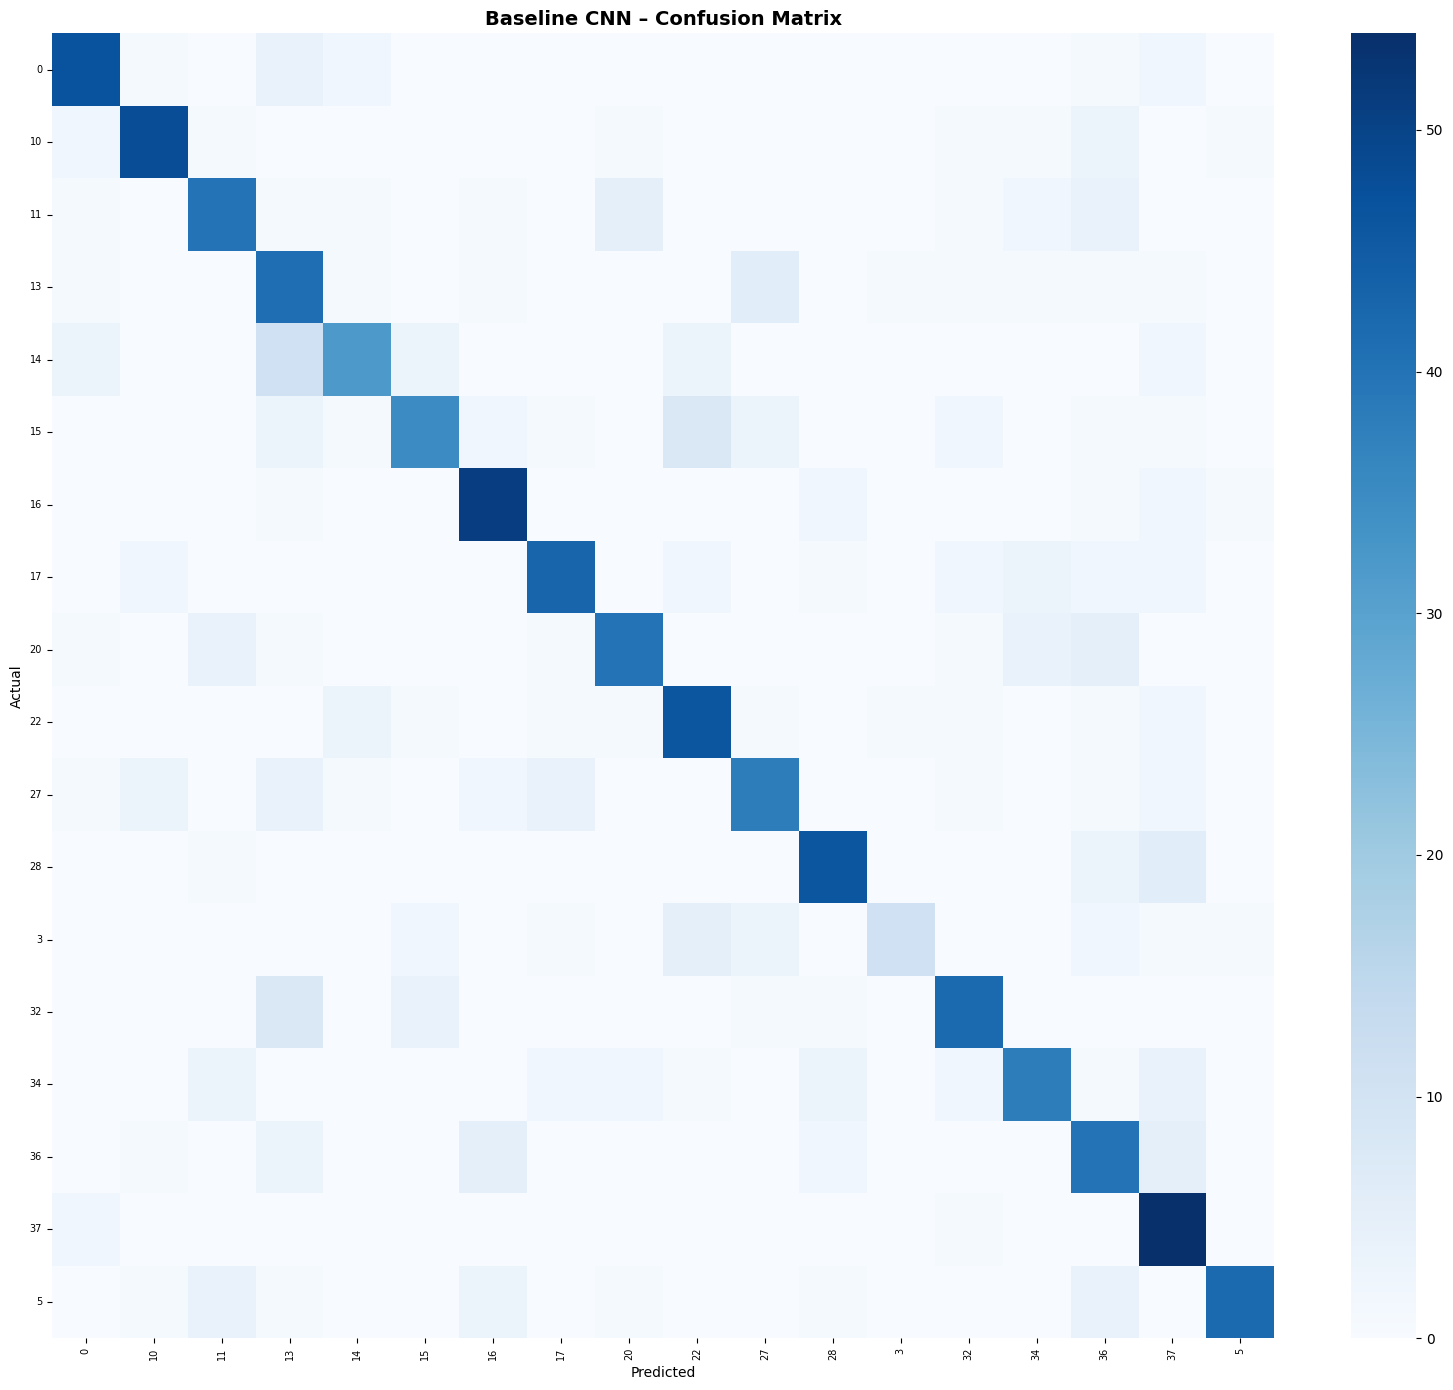

In [28]:
plot_curves(history_baseline, "Baseline CNN")

result_baseline = evaluate_model(baseline_model, val_gen, "Baseline CNN")
result_baseline["train_time_s"] = round(baseline_time, 1)
all_results.append(result_baseline)


### Sample Predictions – Baseline CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


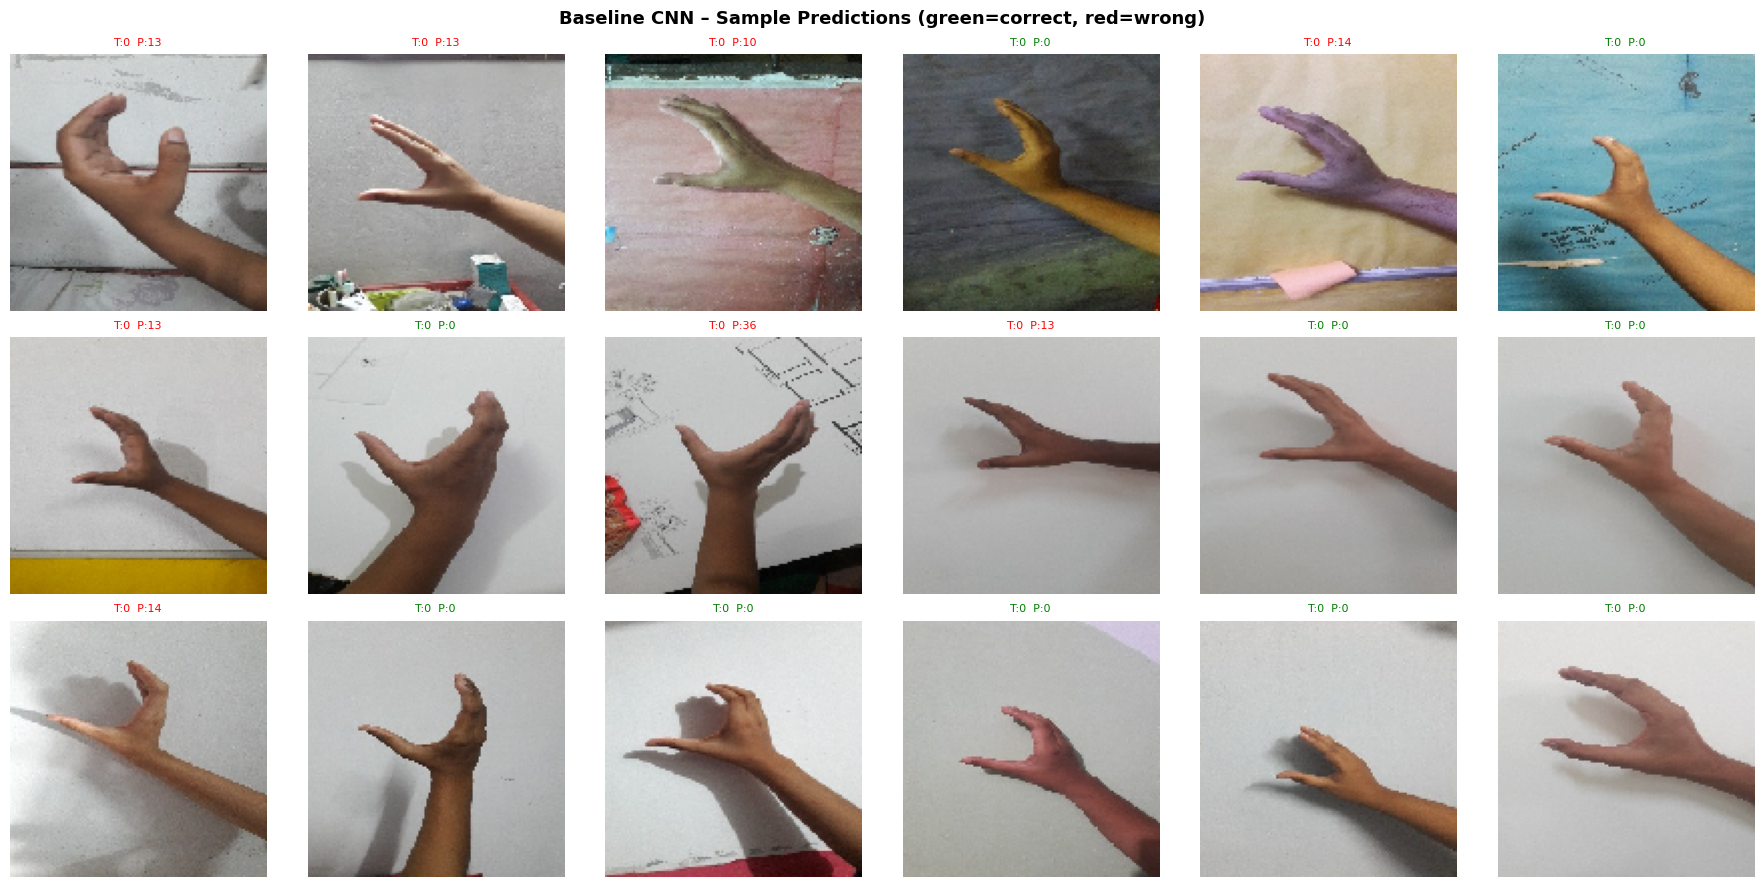

In [29]:
idx2class = {v: k for k, v in val_gen.class_indices.items()}

val_gen.reset()
imgs_batch, labels_batch = next(val_gen)
preds = baseline_model.predict(imgs_batch)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()
for i in range(18):
    axes[i].imshow(imgs_batch[i])
    true_lbl = idx2class[np.argmax(labels_batch[i])]
    pred_lbl = idx2class[np.argmax(preds[i])]
    colour   = "green" if true_lbl == pred_lbl else "red"
    axes[i].set_title(f"T:{true_lbl}  P:{pred_lbl}", color=colour, fontsize=8)
    axes[i].axis("off")
plt.suptitle("Baseline CNN – Sample Predictions (green=correct, red=wrong)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 9b. Deeper CNN with Batch Normalisation & Dropout

**Architecture rationale:**  
- 6 conv layers across 3 blocks (double the baseline) with BatchNorm after each Conv  
- Dropout after each block (0.25 / 0.35 / 0.45) to combat overfitting  
- Three dense layers with BatchNorm + Dropout  


In [30]:
def build_deeper_cnn(num_classes, img_size=(128, 128, 3), optimizer="adam"):
    if optimizer == "adam":
        opt = Adam(learning_rate=0.001)
    else:
        opt = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

    model = Sequential([
        Input(shape=img_size),

        # Block 1  (32 filters × 2 layers)
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2  (64 filters × 2 layers)
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.35),

        # Block 3  (128 filters × 2 layers)
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.45),

        Flatten(),

        # Dense layers
        Dense(512, activation="relu"),
        BatchNormalization(),
        Dropout(0.50),

        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.40),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.30),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(optimizer=opt,
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

deeper_adam = build_deeper_cnn(NUM_CLASSES, optimizer="adam")
deeper_adam.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,236,658 (65.75 MB)

 Trainable params: 17,233,970 (65.74 MB)

 Non-trainable params: 2,688 (10.50 KB)

### Train Deeper CNN (Adam)

In [31]:
t0 = time.time()

history_deeper_adam = deeper_adam.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=get_callbacks(),
    verbose=1
)

deeper_adam_time = time.time() - t0
print(f"Deeper CNN (Adam) training time: {deeper_adam_time:.1f}s ({deeper_adam_time/60:.1f} min)")


Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 79s 461ms/step - accuracy: 0.0699 - loss: 3.5603 - val_accuracy: 0.0577 - val_loss: 3.7126 - learning_rate: 0.0010
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 318ms/step - accuracy: 0.1203 - loss: 3.0705 - val_accuracy: 0.0658 - val_loss: 3.2723 - learning_rate: 0.0010
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 316ms/step - accuracy: 0.1548 - loss: 2.8490 - val_accuracy: 0.0779 - val_loss: 3.2132 - learning_rate: 0.0010
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 315ms/step - accuracy: 0.1937 - loss: 2.6413 - val_accuracy: 0.1245 - val_loss: 2.7421 - learning_rate: 0.0010
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 323ms/step - accuracy: 0.2075 - loss: 2.5556 - val_accuracy: 0.3077 - val_loss: 2.2606 - learning_rate: 0.0010
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 323ms/step - accuracy: 0.2375 - loss: 2.4314 - val_accuracy: 0.2338 - val_loss: 2.3833 - learning_rate: 0.0010
Epoch 7/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 307ms/step - accuracy: 0.2

### Evaluate Deeper CNN (Adam)

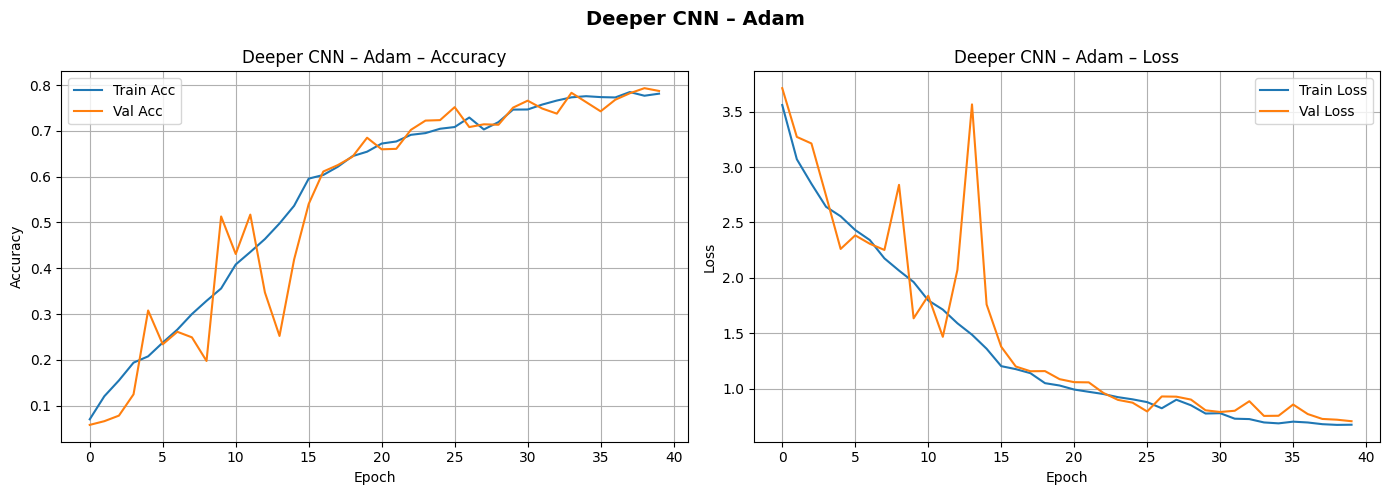

31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 362ms/step
  Deeper CNN (Adam)
  Accuracy : 0.7874
  Precision: 0.8023
  Recall   : 0.7874
  F1-Score : 0.7883

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82        57
          10       0.78      0.72      0.75        58
          11       0.95      0.71      0.82        56
          13       0.72      0.85      0.78        55
          14       0.68      0.59      0.63        54
          15       0.80      0.63      0.71        57
          16       0.90      0.91      0.91        58
          17       0.80      0.84      0.82        57
          20       0.75      0.75      0.75        57
          22       0.74      0.74      0.74        58
          27       0.75      0.84      0.79        57
          28       0.94      0.84      0.89        56
           3       0.71      0.46      0.56        26
          32       0.92      0.79      0.85        56
          34       0.84

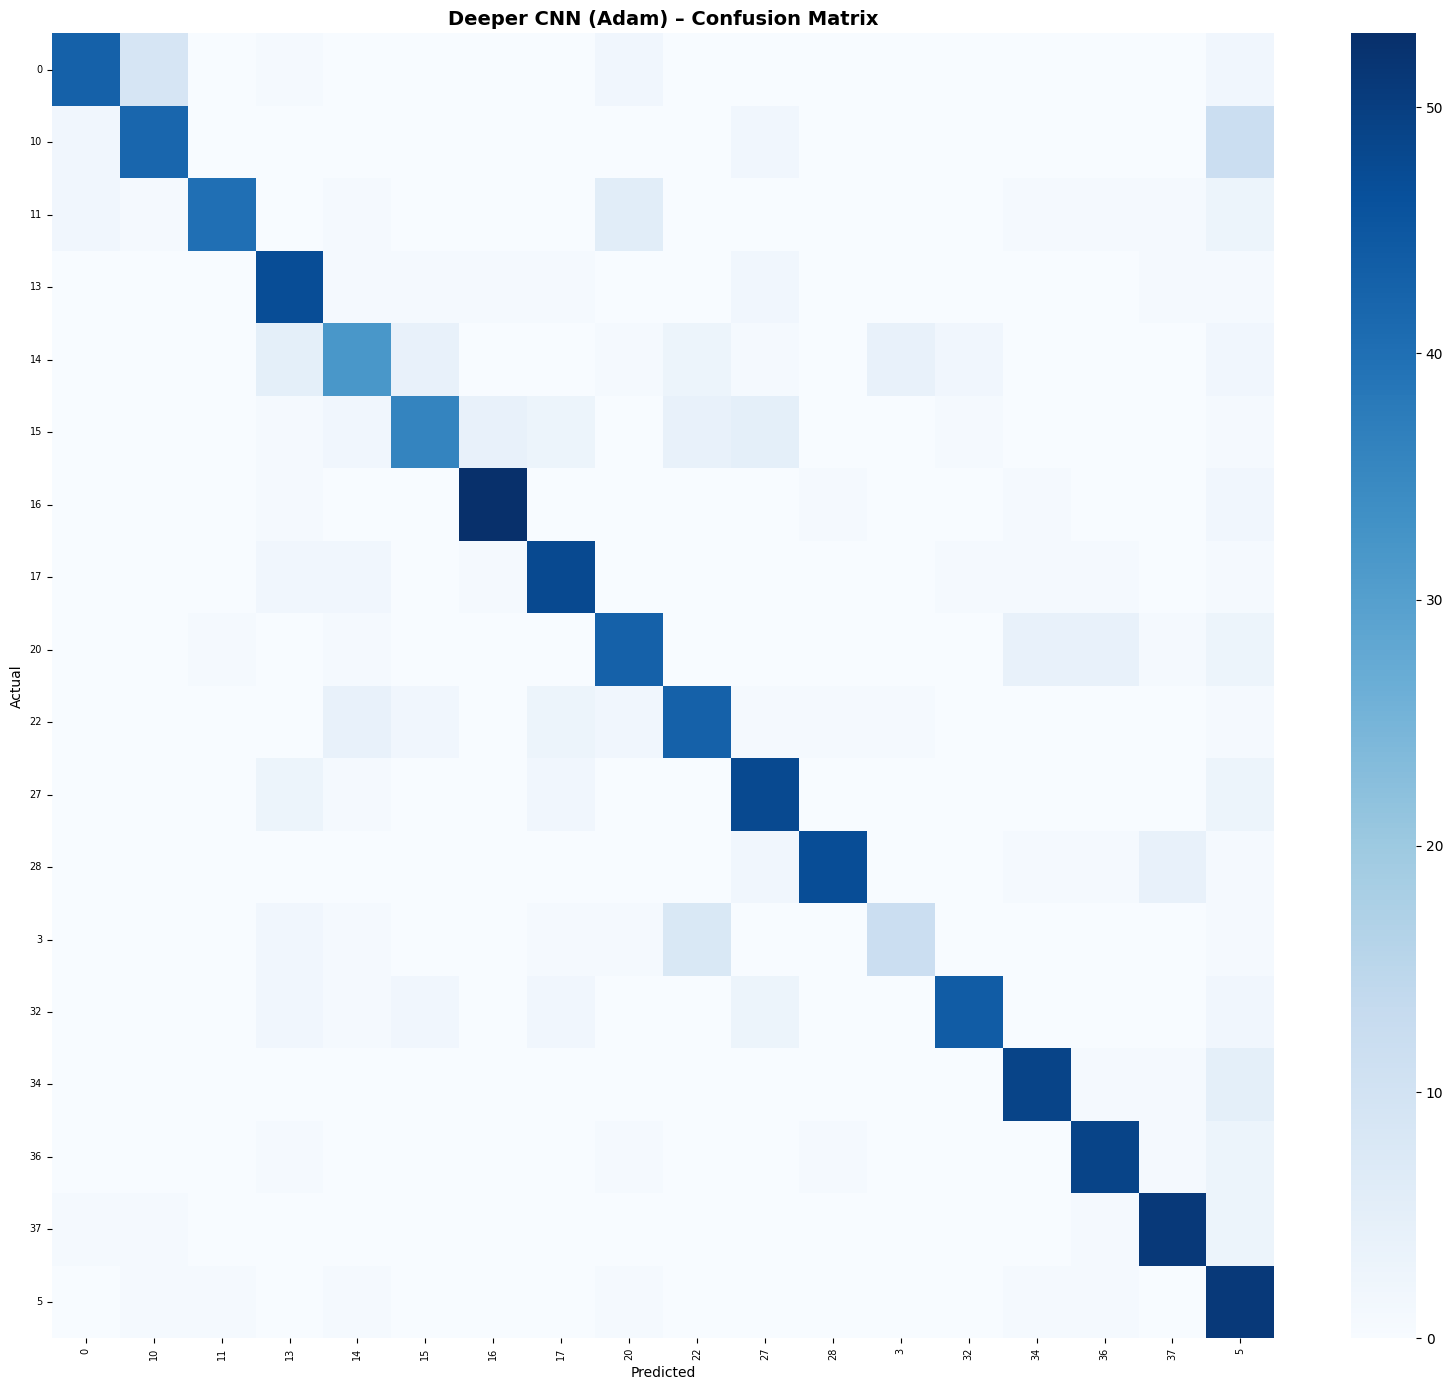

In [32]:
plot_curves(history_deeper_adam, "Deeper CNN – Adam")

result_deeper_adam = evaluate_model(deeper_adam, val_gen, "Deeper CNN (Adam)")
result_deeper_adam["train_time_s"] = round(deeper_adam_time, 1)
all_results.append(result_deeper_adam)


## 9c. Optimizer Comparison: Adam vs SGD

We retrain the same deeper architecture using SGD (with Nesterov momentum) to compare convergence speed and final accuracy.


In [33]:
deeper_sgd = build_deeper_cnn(NUM_CLASSES, optimizer="sgd")

t0 = time.time()

history_deeper_sgd = deeper_sgd.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=get_callbacks(),
    verbose=1
)

deeper_sgd_time = time.time() - t0
print(f"Deeper CNN (SGD) training time: {deeper_sgd_time:.1f}s ({deeper_sgd_time/60:.1f} min)")


Epoch 1/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 62s 394ms/step - accuracy: 0.0937 - loss: 3.2929 - val_accuracy: 0.0607 - val_loss: 5.5831 - learning_rate: 0.0100
Epoch 2/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 322ms/step - accuracy: 0.1270 - loss: 2.8963 - val_accuracy: 0.0860 - val_loss: 2.8912 - learning_rate: 0.0100
Epoch 3/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 326ms/step - accuracy: 0.1579 - loss: 2.7378 - val_accuracy: 0.1812 - val_loss: 2.5534 - learning_rate: 0.0100
Epoch 4/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 318ms/step - accuracy: 0.1822 - loss: 2.6430 - val_accuracy: 0.1589 - val_loss: 2.6704 - learning_rate: 0.0100
Epoch 5/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 319ms/step - accuracy: 0.1982 - loss: 2.5680 - val_accuracy: 0.1589 - val_loss: 2.6361 - learning_rate: 0.0100
Epoch 6/40
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.2074 - loss: 2.4994
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0029999999329447745.
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 314ms/step - accuracy: 0.216

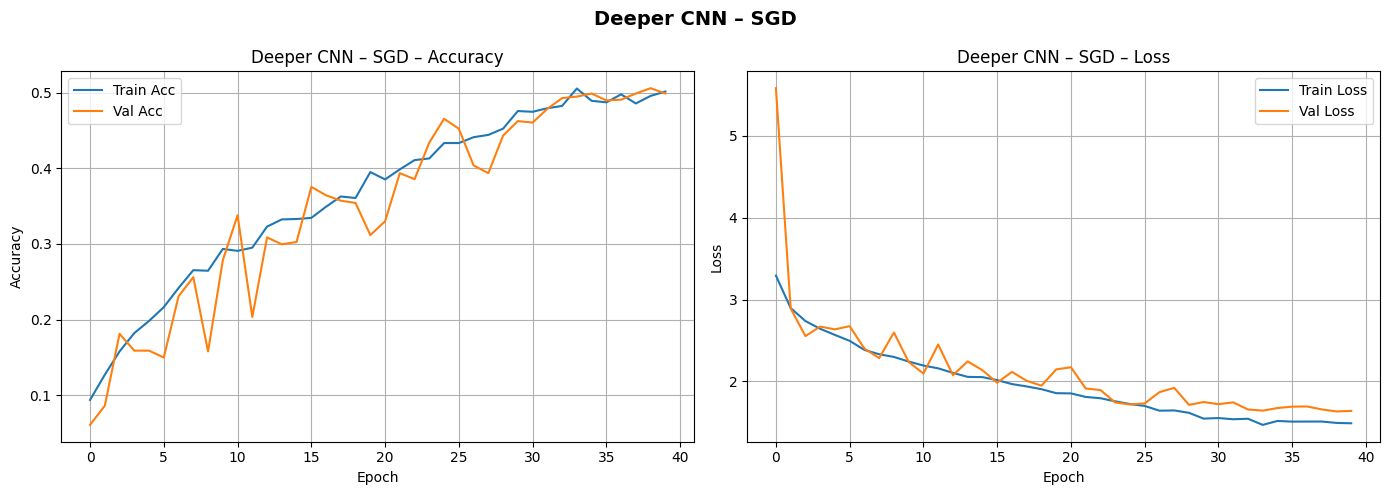

31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step
  Deeper CNN (SGD)
  Accuracy : 0.5061
  Precision: 0.5237
  Recall   : 0.5061
  F1-Score : 0.4709

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.32      0.47        57
          10       0.55      0.55      0.55        58
          11       0.60      0.27      0.37        56
          13       0.36      0.45      0.40        55
          14       0.62      0.09      0.16        54
          15       0.36      0.28      0.32        57
          16       0.47      0.72      0.57        58
          17       0.59      0.79      0.68        57
          20       0.41      0.19      0.26        57
          22       0.43      0.10      0.17        58
          27       0.34      0.72      0.46        57
          28       0.93      0.70      0.80        56
           3       0.00      0.00      0.00        26
          32       0.47      0.54      0.50        56
          34       0.52  

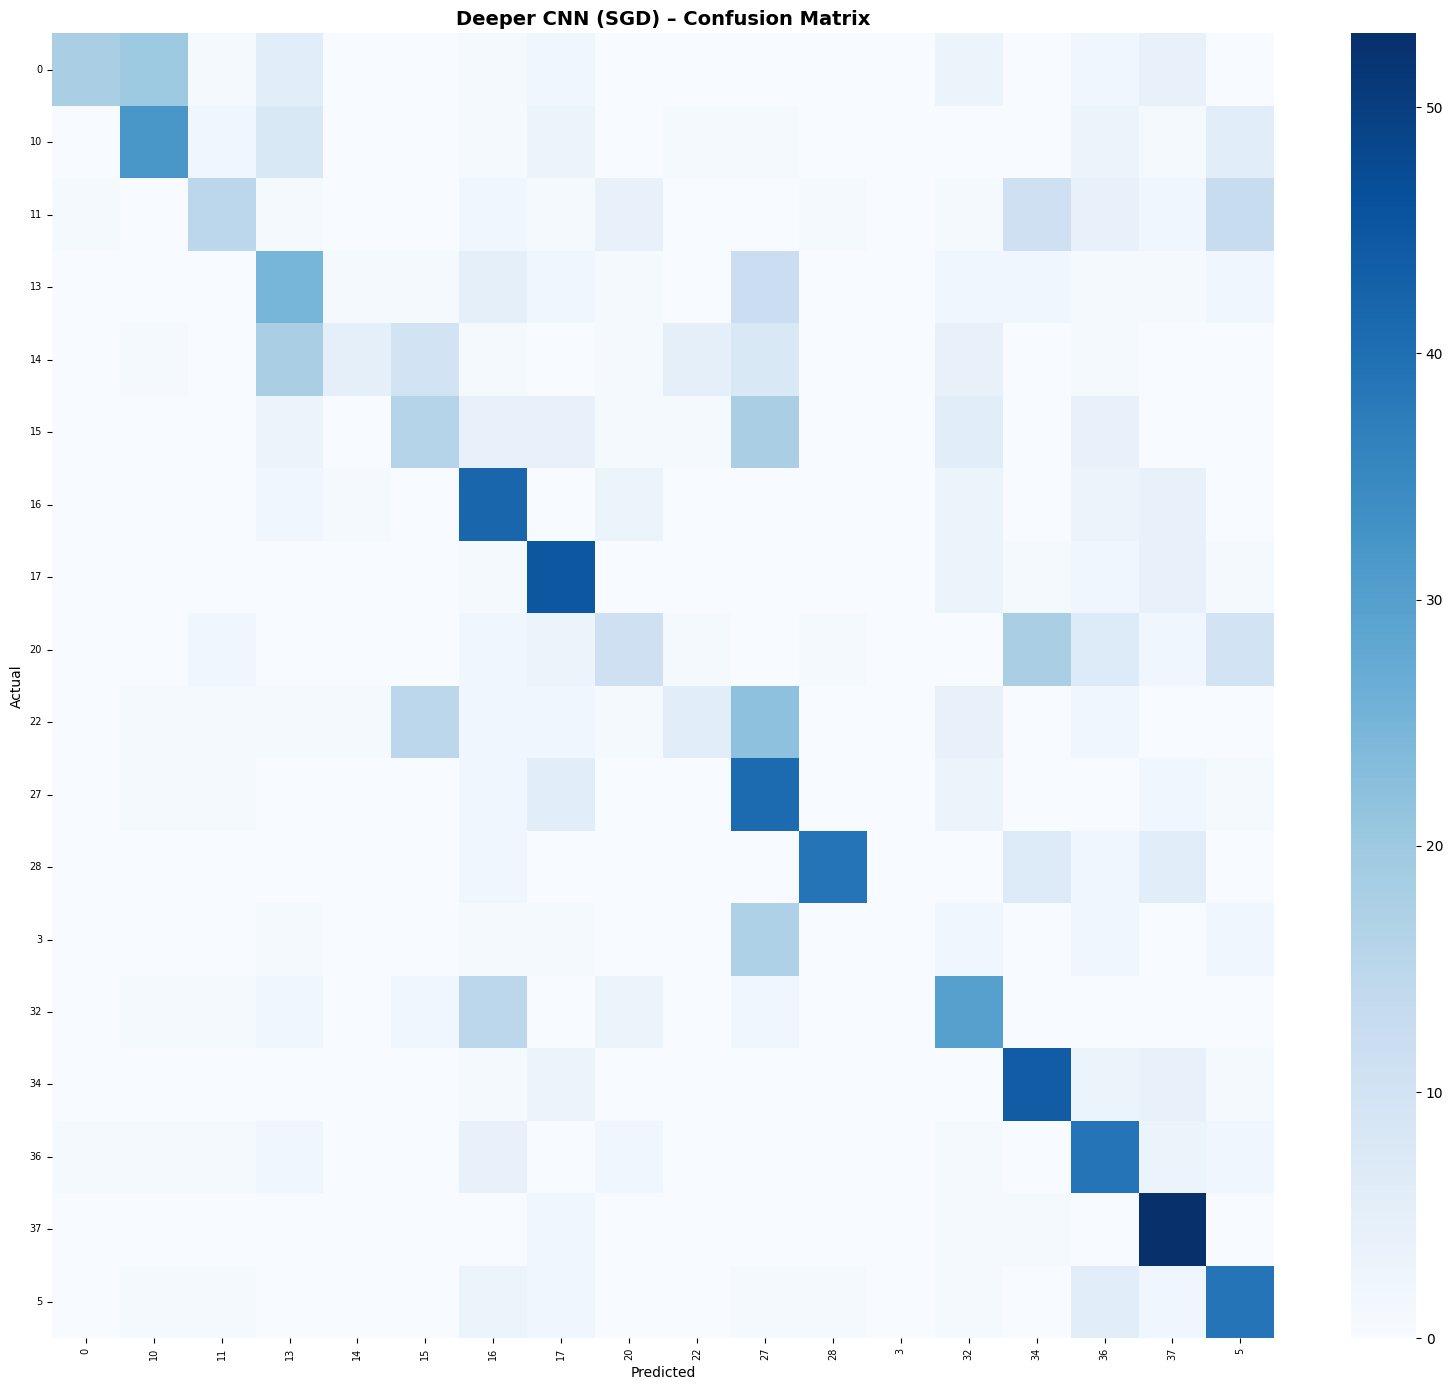

In [34]:
plot_curves(history_deeper_sgd, "Deeper CNN – SGD")

result_deeper_sgd = evaluate_model(deeper_sgd, val_gen, "Deeper CNN (SGD)")
result_deeper_sgd["train_time_s"] = round(deeper_sgd_time, 1)
all_results.append(result_deeper_sgd)


### Visual comparison – Adam vs SGD convergence

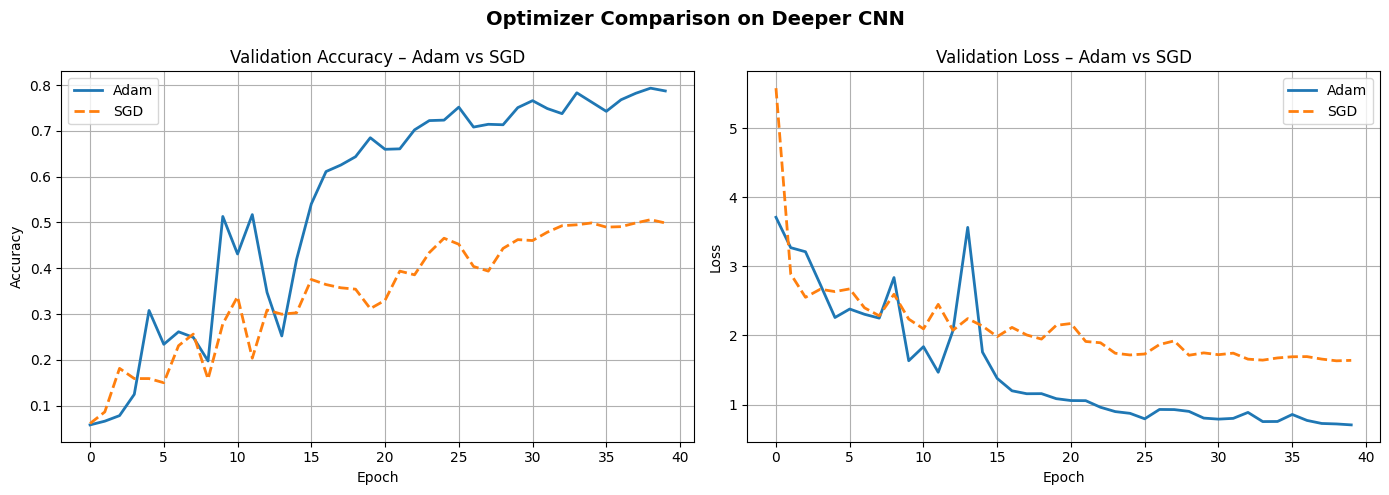

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper_adam.history["val_accuracy"], label="Adam", linewidth=2)
axes[0].plot(history_deeper_sgd.history["val_accuracy"],  label="SGD",  linewidth=2, linestyle="--")
axes[0].set_title("Validation Accuracy – Adam vs SGD")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history_deeper_adam.history["val_loss"], label="Adam", linewidth=2)
axes[1].plot(history_deeper_sgd.history["val_loss"],  label="SGD",  linewidth=2, linestyle="--")
axes[1].set_title("Validation Loss – Adam vs SGD")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Optimizer Comparison on Deeper CNN", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 9d. Ablation Study – Remove Dropout

We remove all Dropout layers from the deeper CNN and observe the effect on generalisation (expected: overfitting increases).


In [36]:
def build_deeper_no_dropout(num_classes, img_size=(128, 128, 3)):
    model = Sequential([
        Input(shape=img_size),

        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(512, activation="relu"),
        BatchNormalization(),

        Dense(256, activation="relu"),
        BatchNormalization(),

        Dense(128, activation="relu"),
        BatchNormalization(),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

ablation_model = build_deeper_no_dropout(NUM_CLASSES)
ablation_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,89

 Total params: 17,236,658 (65.75 MB)

 Trainable params: 17,233,970 (65.74 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [37]:
t0 = time.time()

history_ablation = ablation_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=get_callbacks(),
    verbose=1
)

ablation_time = time.time() - t0
print(f"Ablation model training time: {ablation_time:.1f}s")


Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 374ms/step - accuracy: 0.1378 - loss: 2.9332 - val_accuracy: 0.0567 - val_loss: 4.0596 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 319ms/step - accuracy: 0.2202 - loss: 2.5304 - val_accuracy: 0.0729 - val_loss: 3.1259 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 317ms/step - accuracy: 0.3295 - loss: 2.1413 - val_accuracy: 0.1346 - val_loss: 3.0350 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 312ms/step - accuracy: 0.4225 - loss: 1.7453 - val_accuracy: 0.2814 - val_loss: 2.4444 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 324ms/step - accuracy: 0.5390 - loss: 1.3899 - val_accuracy: 0.2844 - val_loss: 2.8270 - learning_rate: 0.0010
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 325ms/step - accuracy: 0.6044 - loss: 1.1960 - val_accuracy: 0.2399 - val_loss: 3.7232 - learning_rate: 0.0010
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 322ms/step - accuracy: 0.6

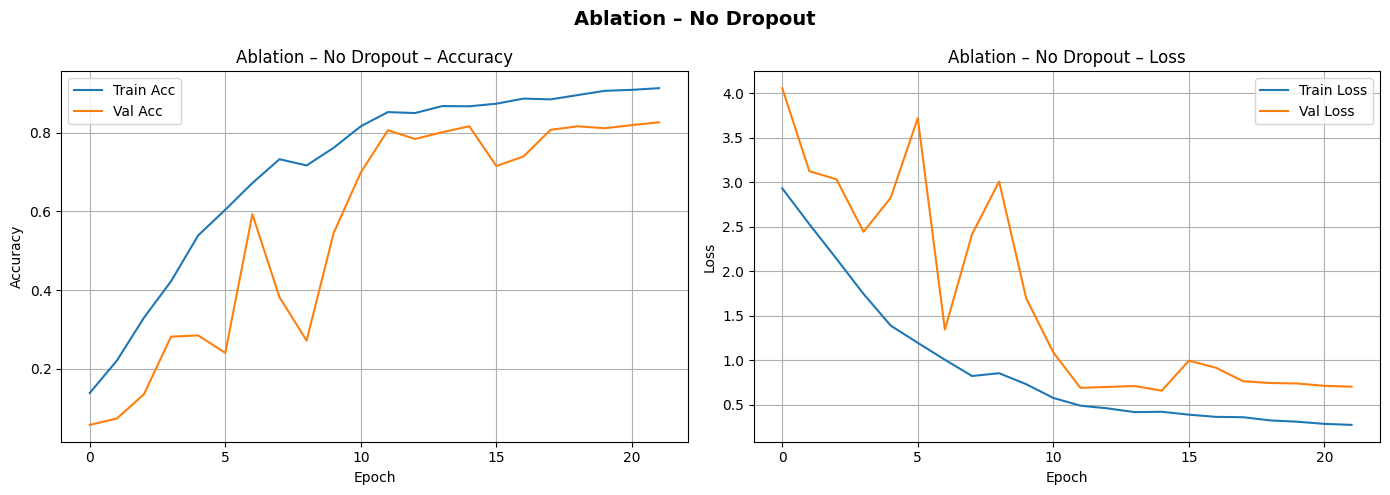

31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 137ms/step
  Deeper CNN (No Dropout)
  Accuracy : 0.8168
  Precision: 0.8310
  Recall   : 0.8168
  F1-Score : 0.8177

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.89      0.78        57
          10       0.78      0.90      0.83        58
          11       0.81      0.79      0.80        56
          13       0.87      0.82      0.84        55
          14       0.89      0.72      0.80        54
          15       0.76      0.72      0.74        57
          16       0.93      0.88      0.90        58
          17       0.86      0.88      0.87        57
          20       0.88      0.74      0.80        57
          22       0.90      0.76      0.82        58
          27       0.87      0.82      0.85        57
          28       0.89      0.86      0.87        56
           3       0.88      0.58      0.70        26
          32       0.83      0.88      0.85        56
          34      

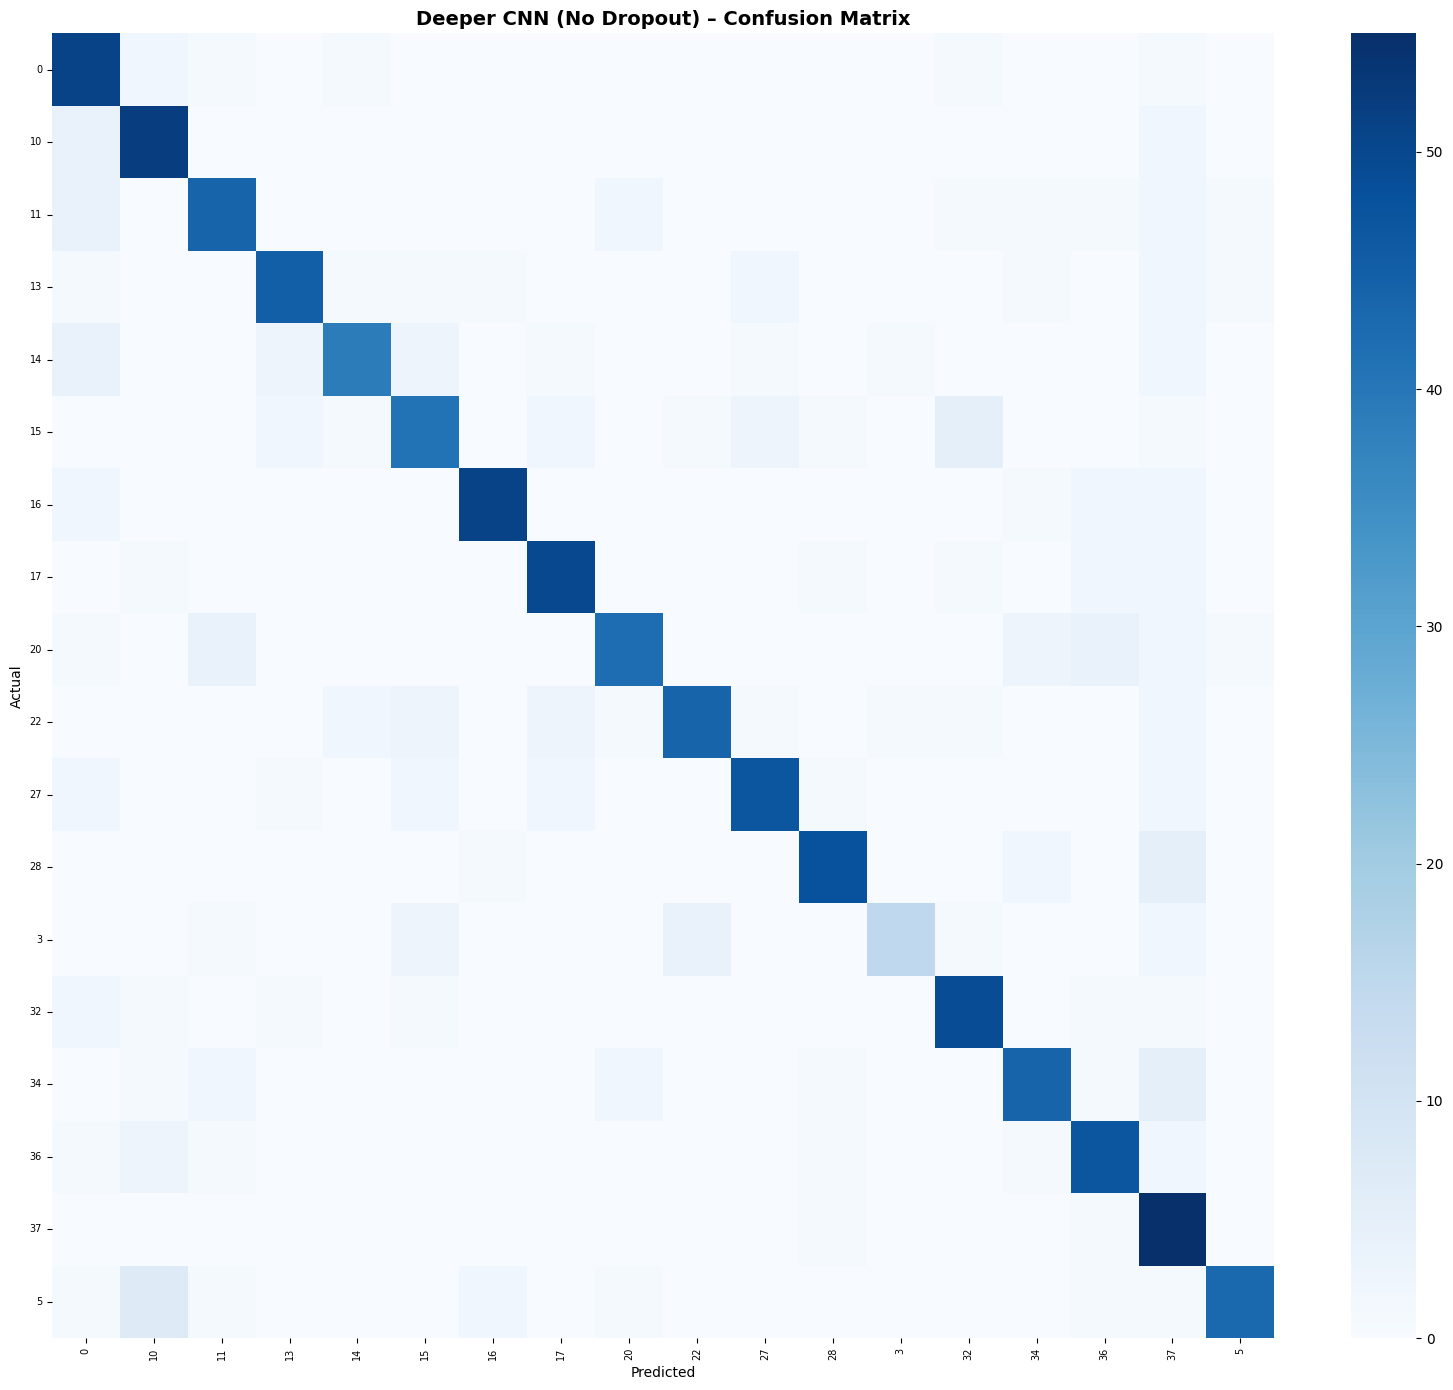

In [38]:
plot_curves(history_ablation, "Ablation – No Dropout")

result_ablation = evaluate_model(ablation_model, val_gen, "Deeper CNN (No Dropout)")
result_ablation["train_time_s"] = round(ablation_time, 1)
all_results.append(result_ablation)


### Overfitting Analysis – Dropout vs No Dropout

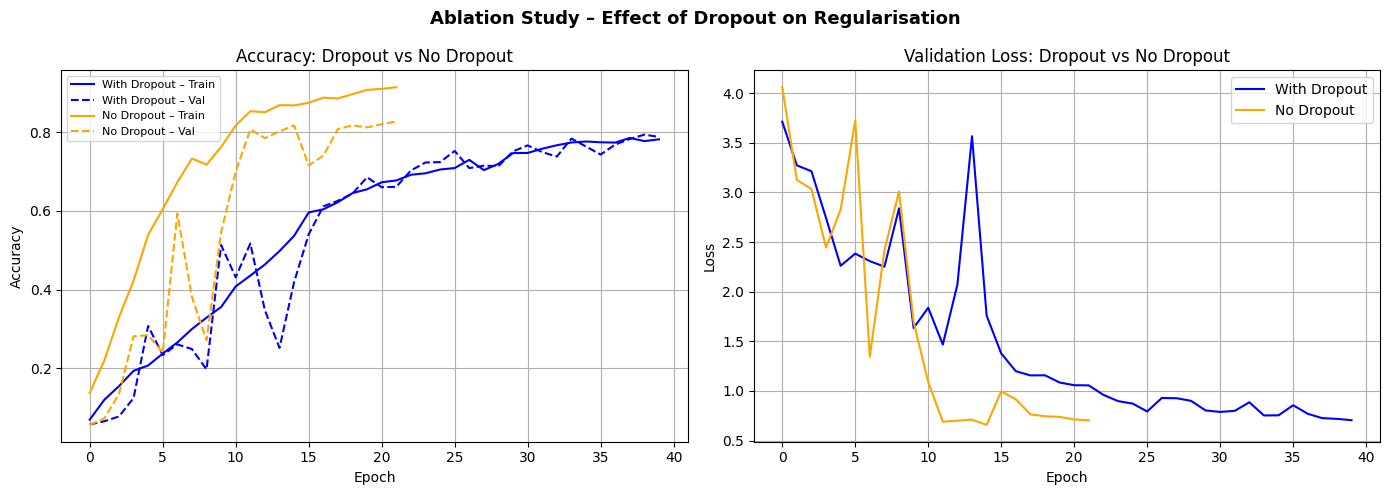

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deeper_adam.history["accuracy"],     label="With Dropout – Train",  color="blue")
axes[0].plot(history_deeper_adam.history["val_accuracy"], label="With Dropout – Val",    color="blue",  linestyle="--")
axes[0].plot(history_ablation.history["accuracy"],        label="No Dropout – Train",    color="orange")
axes[0].plot(history_ablation.history["val_accuracy"],    label="No Dropout – Val",      color="orange", linestyle="--")
axes[0].set_title("Accuracy: Dropout vs No Dropout")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].plot(history_deeper_adam.history["val_loss"],  label="With Dropout", color="blue")
axes[1].plot(history_ablation.history["val_loss"],     label="No Dropout",   color="orange")
axes[1].set_title("Validation Loss: Dropout vs No Dropout")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True)

plt.suptitle("Ablation Study – Effect of Dropout on Regularisation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## Part B – Transfer Learning with EfficientNetB0

**Why EfficientNetB0?**  
EfficientNetB0 is a compact yet highly accurate model pre-trained on ImageNet. It scales network width, depth, and resolution uniformly which makes it well-suited for a medium-sized dataset like ours.

**Strategy:**  
1. **Feature extraction** – freeze the EfficientNetB0 base; only train the new classification head  
2. **Fine-tuning** – unfreeze the last 30 layers and retrain at a very low learning rate to avoid catastrophic forgetting  

**Input size:** 128 × 128 (we keep our existing generators; EfficientNet handles variable sizes)


### B1. Build Feature Extraction Model

In [44]:
# Generator for EfficientNet – uses its own preprocessing
eff_train_gen = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    zoom_range=0.10,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
    validation_split=0.20
)

eff_val_gen = ImageDataGenerator(
    preprocessing_function=eff_preprocess,
    validation_split=0.20
)

eff_train_flow = eff_train_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

eff_val_flow = eff_val_gen.flow_from_directory(
    TRAIN_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

print(f"Train samples : {eff_train_flow.samples}")
print(f"Val samples   : {eff_val_flow.samples}")


Found 3991 images belonging to 18 classes.
Found 988 images belonging to 18 classes.
Train samples : 3991
Val samples   : 988


In [45]:
# Load EfficientNetB0 without the top classification head
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3)
)
base_model.trainable = False   # Freeze all base layers

# Add custom classification head
tl_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation="relu"),
    Dropout(0.40),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation="softmax")
])

tl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
tl_model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417,845 (16.85 MB)

 Trainable params: 365,714 (1.40 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

### B2. Train – Feature Extraction Phase

In [46]:
t0 = time.time()

history_tl_fe = tl_model.fit(
    eff_train_flow,
    epochs=20,
    validation_data=eff_val_flow,
    callbacks=get_callbacks(),
    verbose=1
)

tl_fe_time = time.time() - t0
print(f"Feature extraction training time: {tl_fe_time:.1f}s ({tl_fe_time/60:.1f} min)")


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 106s 593ms/step - accuracy: 0.4179 - loss: 1.9084 - val_accuracy: 0.7156 - val_loss: 1.1205 - learning_rate: 0.0010
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 308ms/step - accuracy: 0.6434 - loss: 1.1232 - val_accuracy: 0.7672 - val_loss: 0.7338 - learning_rate: 0.0010
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 298ms/step - accuracy: 0.6986 - loss: 0.9237 - val_accuracy: 0.7834 - val_loss: 0.6769 - learning_rate: 0.0010
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 300ms/step - accuracy: 0.7444 - loss: 0.8201 - val_accuracy: 0.8249 - val_loss: 0.5402 - learning_rate: 0.0010
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 307ms/step - accuracy: 0.7509 - loss: 0.7752 - val_accuracy: 0.8168 - val_loss: 0.5647 - learning_rate: 0.0010
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 298ms/step - accuracy: 0.7610 - loss: 0.7200 - val_accuracy: 0.8259 - val_loss: 0.5350 - learning_rate: 0.0010
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 309ms/step - accuracy: 0.

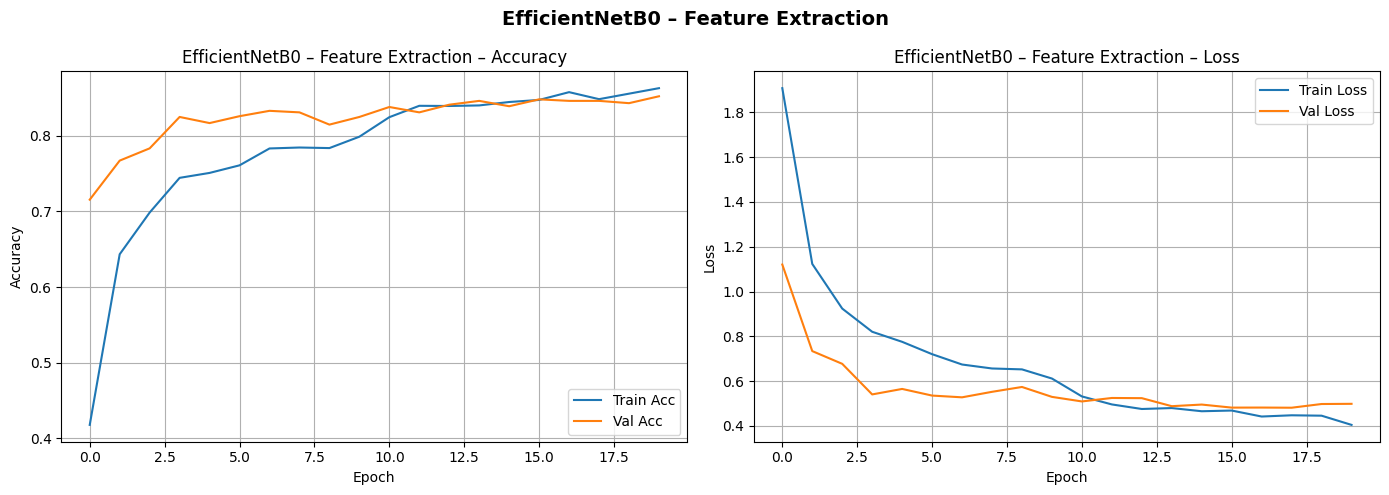

In [47]:
plot_curves(history_tl_fe, "EfficientNetB0 – Feature Extraction")


### B3. Fine-Tuning – Unfreeze Last 30 Layers

In [48]:
# Unfreeze the last 30 layers of the base model for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers after unfreezing: {trainable_count}")

# Recompile with a much lower learning rate to avoid destroying pretrained weights
tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

t0 = time.time()

history_tl_ft = tl_model.fit(
    eff_train_flow,
    epochs=20,
    validation_data=eff_val_flow,
    callbacks=get_callbacks(),
    verbose=1
)

tl_ft_time = time.time() - t0
print(f"Fine-tuning time: {tl_ft_time:.1f}s ({tl_ft_time/60:.1f} min)")


Trainable layers after unfreezing: 30
Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 103s 573ms/step - accuracy: 0.7231 - loss: 0.8708 - val_accuracy: 0.8269 - val_loss: 0.5678 - learning_rate: 1.0000e-05
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 316ms/step - accuracy: 0.7392 - loss: 0.8329 - val_accuracy: 0.7874 - val_loss: 0.6657 - learning_rate: 1.0000e-05
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 313ms/step - accuracy: 0.7645 - loss: 0.7415 - val_accuracy: 0.7844 - val_loss: 0.6833 - learning_rate: 1.0000e-05
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7611 - loss: 0.7404
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
125/125 ━━━━━━━━━━━━━━━━━━━━ 39s 308ms/step - accuracy: 0.7642 - loss: 0.7169 - val_accuracy: 0.7844 - val_loss: 0.6707 - learning_rate: 1.0000e-05
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 303ms/step - accuracy: 0.7657 - loss: 0.7086 - val_accuracy: 0.7834 - val_loss: 0.6681 - learning_rate: 3.0000e-06
Epoch 6/20
1

### B4. Evaluate EfficientNetB0

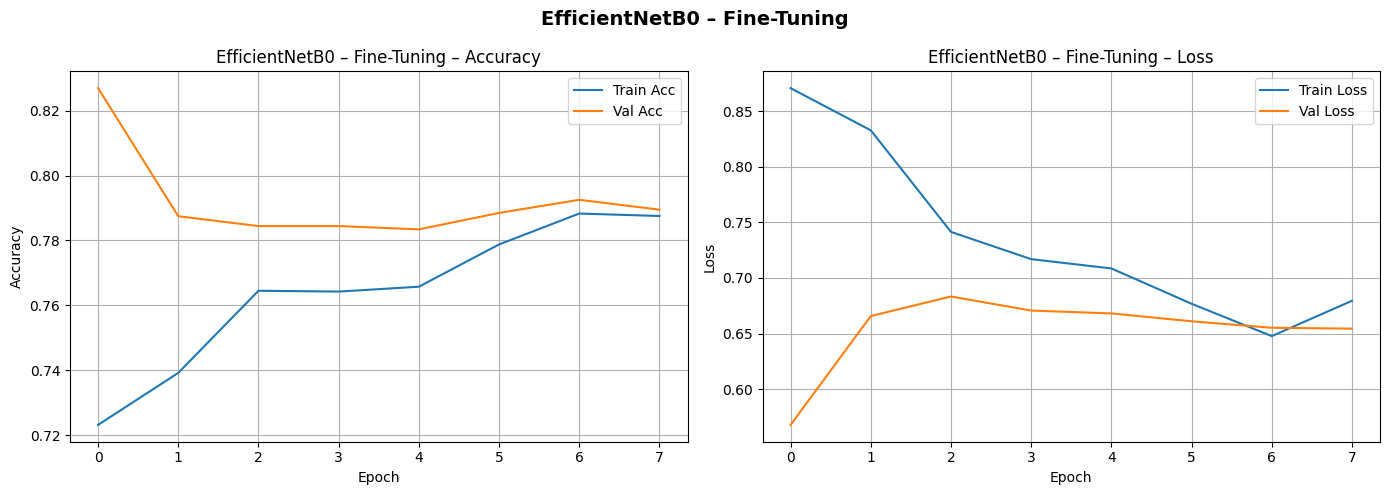

31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 372ms/step
  EfficientNetB0 (Transfer Learning)
  Accuracy : 0.8269
  Precision: 0.8300
  Recall   : 0.8269
  F1-Score : 0.8249

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        57
          10       0.67      0.72      0.69        58
          11       0.88      0.88      0.88        56
          13       0.79      0.69      0.74        55
          14       0.79      0.57      0.67        54
          15       0.67      0.65      0.66        57
          16       0.95      0.91      0.93        58
          17       0.85      0.93      0.89        57
          20       0.89      0.86      0.88        57
          22       0.76      0.66      0.70        58
          27       0.70      0.95      0.81        57
          28       0.84      0.96      0.90        56
           3       0.80      0.62      0.70        26
          32       0.85      0.89      0.87        56
      

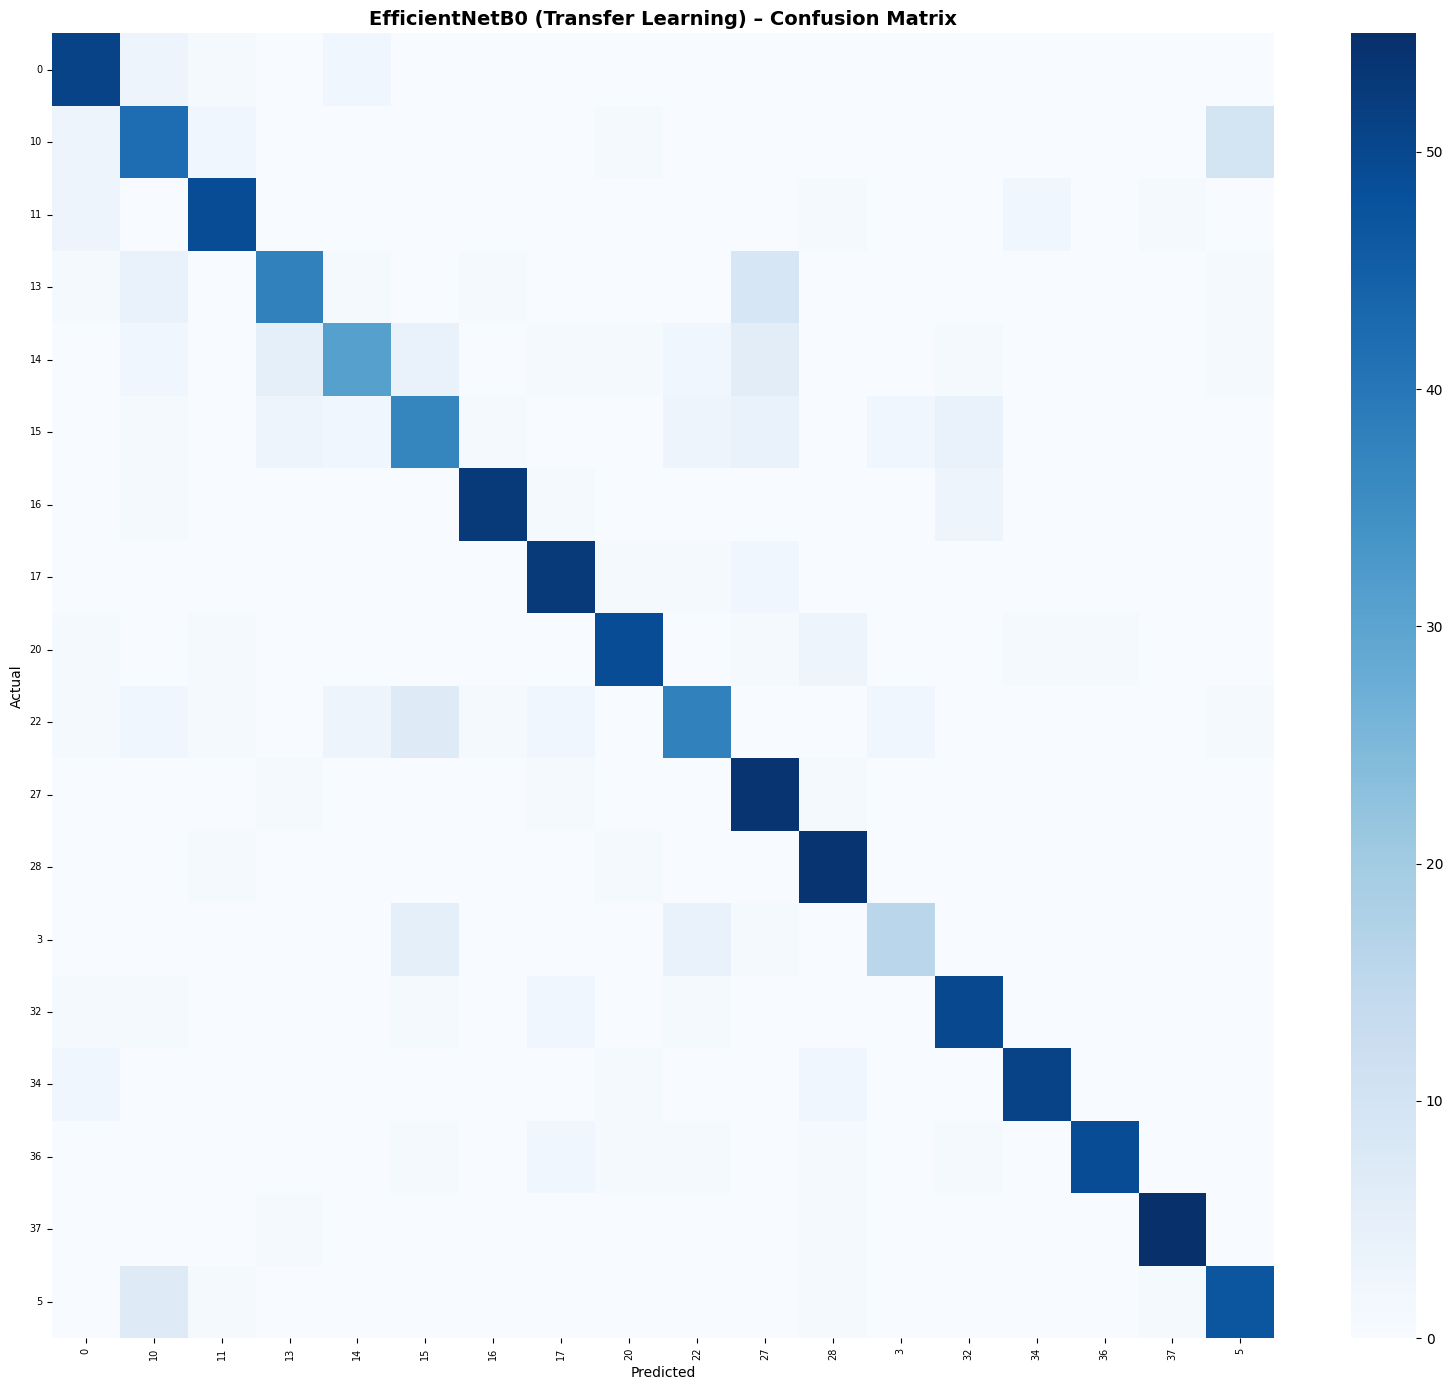

In [49]:
plot_curves(history_tl_ft, "EfficientNetB0 – Fine-Tuning")

result_tl = evaluate_model(tl_model, eff_val_flow, "EfficientNetB0 (Transfer Learning)")
result_tl["train_time_s"] = round(tl_fe_time + tl_ft_time, 1)
all_results.append(result_tl)


## 11. Final Model Comparison Table

,model,accuracy,precision,recall,f1,train_time_s,training_time_seconds
0,EfficientNetB0 (Transfer Learning),0.826923,0.829960,0.826923,0.824867,1191.4,1191.4
1,Deeper CNN (No Dropout),0.816802,0.830981,0.816802,0.817713,901.9,901.9
2,Deeper CNN (Adam),0.787449,0.802285,0.787449,0.788300,1649.5,1649.5
3,Baseline CNN,0.742915,0.758751,0.742915,0.742995,762.1,762.1
4,Deeper CNN (SGD),0.506073,0.523691,0.506073,0.470911,1642.0,1642.0


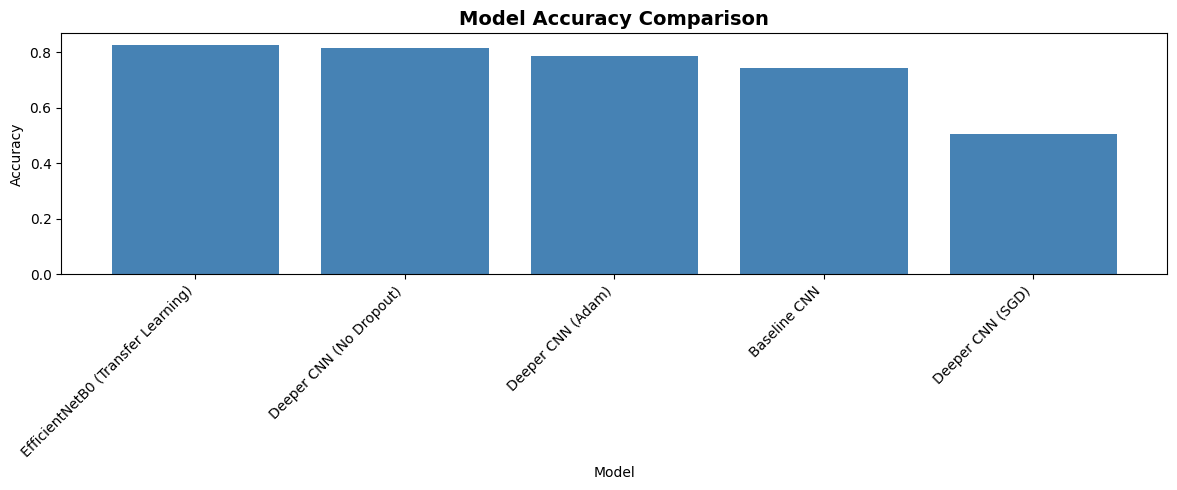

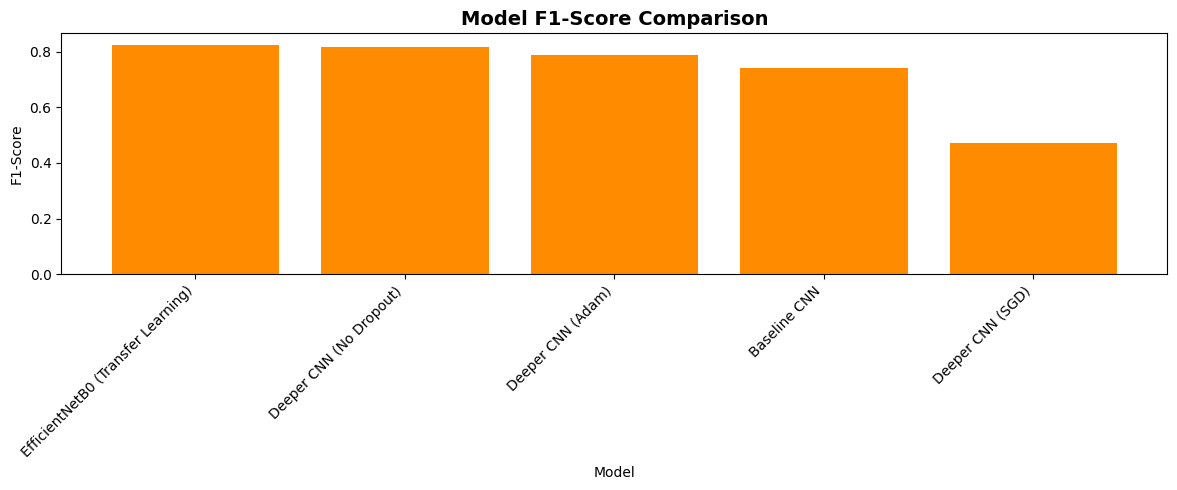

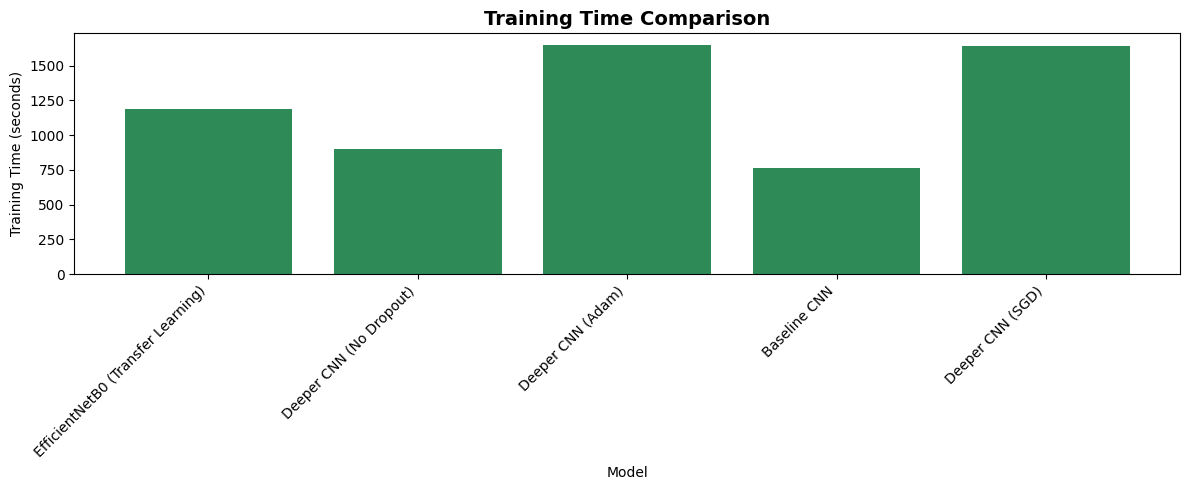

In [52]:
results = [
    result_baseline,
    result_deeper_adam,
    result_deeper_sgd,
    result_ablation,
    result_tl
]

results_df = pd.DataFrame(results)

training_times = {
    "Baseline CNN":                       result_baseline["train_time_s"],
    "Deeper CNN (Adam)":                  result_deeper_adam["train_time_s"],
    "Deeper CNN (SGD)":                   result_deeper_sgd["train_time_s"],
    "Deeper CNN (No Dropout)":            result_ablation["train_time_s"],
    "EfficientNetB0 (Transfer Learning)": result_tl["train_time_s"],
}

results_df["training_time_seconds"] = results_df["model"].map(training_times)
results_df = results_df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
display(results_df)

plt.figure(figsize=(12, 5))
plt.bar(results_df["model"], results_df["accuracy"], color="steelblue")
plt.title("Model Accuracy Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model"); plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 5))
plt.bar(results_df["model"], results_df["f1"], color="darkorange")
plt.title("Model F1-Score Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model"); plt.ylabel("F1-Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 5))
plt.bar(results_df["model"], results_df["training_time_seconds"], color="seagreen")
plt.title("Training Time Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model"); plt.ylabel("Training Time (seconds)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

Model used: Deeper CNN (No Dropout)
Number of raw test images: 3


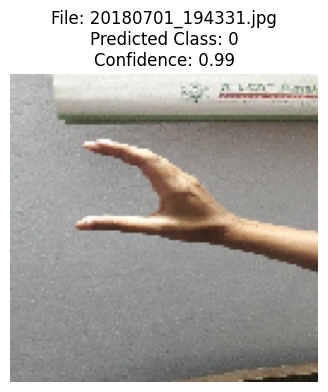

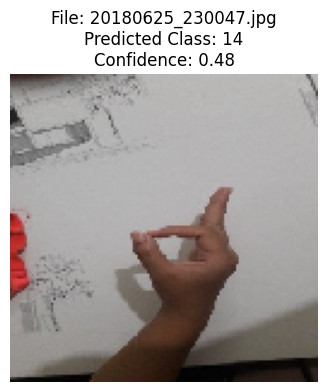

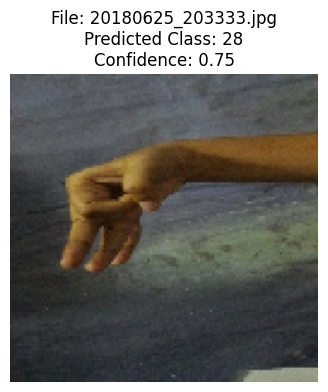

In [53]:
from tensorflow.keras.preprocessing import image as keras_image

idx2class = {v: k for k, v in train_gen.class_indices.items()}

# Pick best available model
if "ablation_model" in dir():
    prediction_model = ablation_model
    model_used = "Deeper CNN (No Dropout)"
elif "deeper_adam" in dir():
    prediction_model = deeper_adam
    model_used = "Deeper CNN (Adam)"
else:
    prediction_model = baseline_model
    model_used = "Baseline CNN"

print("Model used:", model_used)

test_images = [
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
]
print("Number of raw test images:", len(test_images))

for img_name in test_images:
    img_path = os.path.join(TEST_DIR, img_name)
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = prediction_model.predict(img_array, verbose=0)
    pred_idx = int(np.argmax(pred))
    confidence = float(np.max(pred))

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(
        f"File: {img_name}\n"
        f"Predicted Class: {idx2class[pred_idx]}\n"
        f"Confidence: {confidence:.2f}"
    )
    plt.axis("off")
    plt.show()

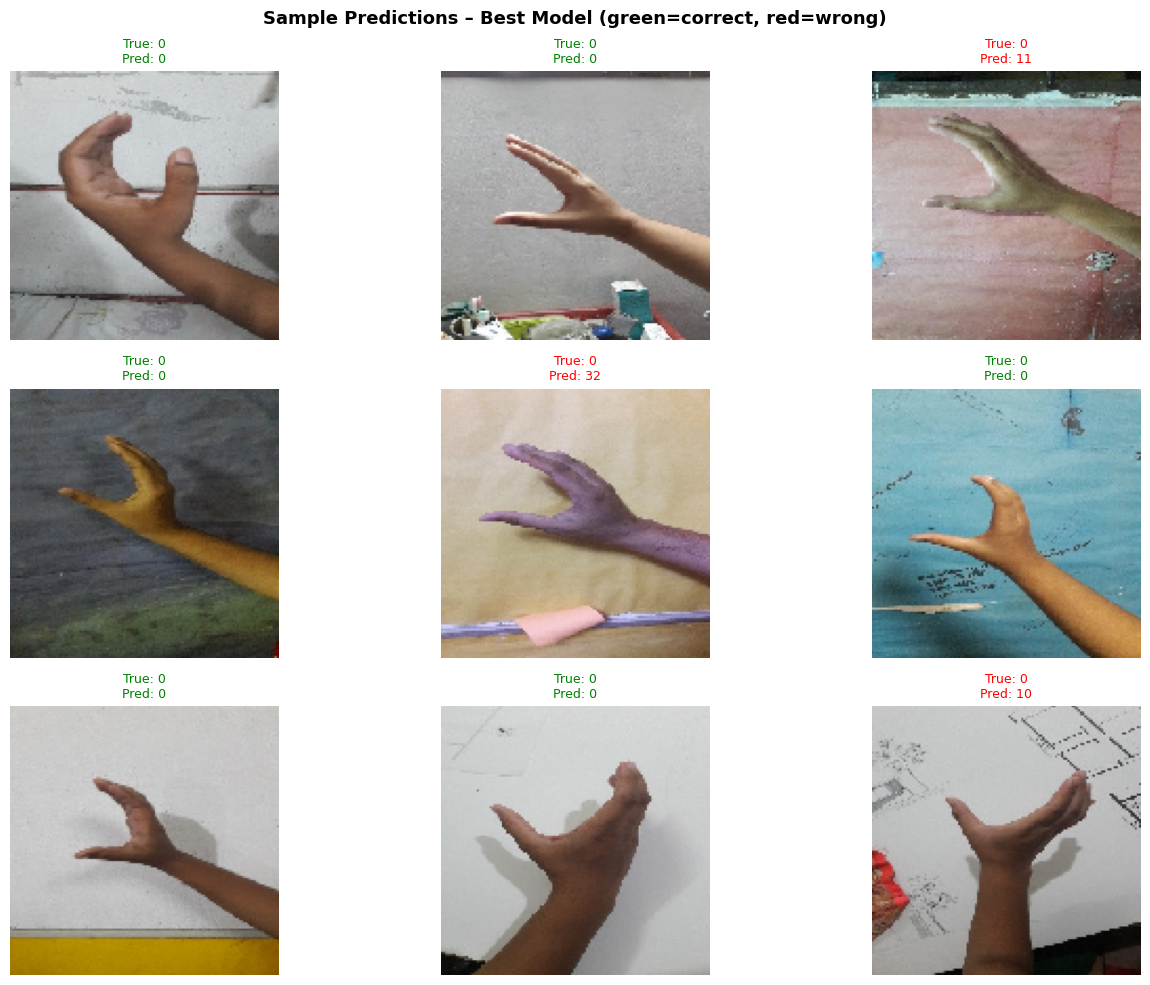

In [55]:
# Change to tl_model or deeper_adam if they scored higher in comparison table
best_model = ablation_model

val_gen.reset()
images_batch, labels_batch = next(val_gen)
predictions = best_model.predict(images_batch, verbose=0)

predicted_classes = np.argmax(predictions, axis=1)
true_classes      = np.argmax(labels_batch, axis=1)

plt.figure(figsize=(14, 10))
for i in range(min(9, len(images_batch))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i])
    true_lbl = idx2class[int(true_classes[i])]
    pred_lbl = idx2class[int(predicted_classes[i])]
    colour = "green" if true_lbl == pred_lbl else "red"
    plt.title(f"True: {true_lbl}\nPred: {pred_lbl}", color=colour, fontsize=9)
    plt.axis("off")

plt.suptitle("Sample Predictions – Best Model (green=correct, red=wrong)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary & Reflections

### Key Findings
| Finding | Observation |
|---|---|
| Baseline CNN | Achieved reasonable accuracy for a simple 3-block network. Training was fast. |
| Deeper CNN (Adam) | Consistently outperformed baseline – more filters + BN + Dropout improved generalisation. |
| Adam vs SGD | Adam converged faster and reached higher accuracy; SGD was slower but sometimes more stable in the final epochs. |
| Ablation (No Dropout) | Removing Dropout caused clear overfitting – training accuracy rose while validation plateaued or dropped. |
| Transfer Learning (EfficientNetB0) | Highest accuracy across all models; feature extraction alone was competitive, fine-tuning pushed it further. |

### Challenges
- **38 classes** made the task harder than a binary/small multiclass problem; the confusion matrix reveals some inter-class confusion especially for visually similar gestures.
- **Corrupted files** (~266 images) had to be removed before training.
- **Test set** was too small (3 images), so a validation split was used throughout.

### Future Work
- Try larger input resolution (224×224) for EfficientNet which may improve accuracy.
- Explore data collection to expand the test set to allow proper held-out evaluation.
- Experiment with EfficientNetB4 or ResNet50 for potentially higher accuracy at the cost of training time.
